# Run the biomod model and project

## Imports and variables

In [ ]:
import imageio
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import os
import pandas as pd
import pygmt
import re
import rioxarray as rio
from scipy.stats import sem 
from scipy.ndimage import gaussian_filter
import shutil
import skimage
import subprocess
import sys
import xarray as xr
import xesmf as xe

In [ ]:
# The PARED datapoints with their paleolatitude and paleolongitude, processed in processPARED.ipynb
pared = pd.read_csv('data/pared_time_pmag.csv')

model = 'earthbyte' # 'scotese' or 'earthbyte'
if model == 'scotese':
    modelName = '2024-10-08_realigned_scotese_paleo_shallowSea'
    topoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
    paleoLon, paleoLat = 'pal_long_scotese', 'pal_lat_scotese'
elif model == 'earthbyte':
    modelName = '2024-07-23_realigned_earthbyte_paleo_PaleomagRef'
    topoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
    paleoLon, paleoLat = 'p_lng_pmag', 'p_lat_pmag'

# Simple two column file that contains the preferred CO2 values for each time slice
CO2File = f'preferredCO2_{modelName}.txt'
co2s = pd.read_csv(CO2File,sep='\t',names=['co2'],index_col=[0])

## Get Ensemble Model

In [ ]:
# Note change so the paleogeography model is an argument
subprocess.call(['Rscript','getEnsembleModel.r'], shell=False)

 library(terra) でエラー:  ‘terra’ という名前のパッケージはありません 
 実行が停止されました 


1

## Get Ensemble Projection

In [ ]:
for age in np.arange(0,260,10):
    print(age)
    co2 = co2s.loc[age][0]
    print(co2)
    subprocess.call(['Rscript','getEnsembleProjection.r', str(age), modelName, co2], shell=False)

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_5305/2237590271.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


0
280


 library(terra) でエラー:  ‘terra’ という名前のパッケージはありません 
 実行が停止されました 
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_5305/2237590271.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


10
fosterCO2


 library(terra) でエラー:  ‘terra’ という名前のパッケージはありません 
 実行が停止されました 
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_5305/2237590271.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


...

 library(terra) でエラー:  ‘terra’ という名前のパッケージはありません 
 実行が停止されました 
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_5305/2237590271.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


240
2240


 library(terra) でエラー:  ‘terra’ という名前のパッケージはありません 
 実行が停止されました 
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_5305/2237590271.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


250
4480


 library(terra) でエラー:  ‘terra’ という名前のパッケージはありません 
 実行が停止されました 


## Clip to shelves


In [ ]:
def clip2shelves(age, ensemblePath, topoPath, dontClip=False):
    # ensembleDS = xr.open_dataset(ensemblePath)
    ensembleDS = rio.open_rasterio(ensemblePath, masked=True)
    # ensembleDS = ensembleDS.to_dataset('band')

    # Convert ensemble to netcdf
    dataType = ['e_mean','cv','e_median','ca','wmean','ciInf', 'ciSup']

    dataName = ['Mean', 'Coefficient of variation', 'Median', 
                'Committee averaging score', 'Weighted mean', 
                'Confidence interval (lower)', 'Confidence interval (upper)']

    k = -1
    for k in range(len(dataType)):
        nda = xr.DataArray(
                        # ensembleDS.isel(band=k).band_data.values,
                        ensembleDS.isel(band=k).values,
                        dims=["lat", "lon"],
                        coords={"lat": ensembleDS.y.values, "lon": ensembleDS.x.values},
                    )

        if k == 0:
            dataEM = nda.to_dataset(name=dataType[k])

        tmp = nda.fillna(0).values
        dataEM[dataType[k]] = (('lat', 'lon'), gaussian_filter(tmp,1))
    if dontClip:
        dataEM['e_mean_shelf'] = dataEM['wmean']
        return dataEM

    # Regrid to 721 x 361
    lon_target = xr.DataArray(np.linspace(-179.25, 179.75, 720), dims='lon')
    lat_target = xr.DataArray(np.linspace(-89.75, 89.75, 360), dims='lat')
    target_grid = xr.Dataset({'lon': lon_target, 'lat': lat_target})

    # Define the regridder
    regridder = xe.Regridder(dataEM, target_grid, method='nearest_s2d')

    # Perform the regridding
    ensembleRegrid = regridder(dataEM)

    # Now bring in the topo grid with shelf data
    tmpGrid = f'tmp_topo_{age}'
    if os.path.exists(tmpGrid):
        os.remove(tmpGrid)

    shutil.copy(topoPath, os.path.join(os.getcwd(), tmpGrid))

    # Open the netCDF file
    topoDS = xr.open_dataset(tmpGrid)
    topoDS = pygmt.grdsample(grid=topoDS['z'],registration='p')

    # # Convert to 0-360
    # topoDS['lon'] = topoDS['lon'].where(topoDS['lon'] >= 0, topoDS['lon'] + 360)
    # topoDS = topoDS.sortby('lon')

    # Define the regridder
    regridder = xe.Regridder(topoDS, target_grid, method='nearest_s2d')
    topoDS = regridder(topoDS)
    # topoDS.plot()
    # sys.exit()

    ensembleRegrid['topo'] = topoDS

    # Extract the shelves
    grid_data = ensembleRegrid['topo']


    # Make every value an integer
    grid_data = grid_data.astype(int)


    # Create a mask for shallow shelf values
    # shelf = (grid_data >= -1500) & (grid_data < 1)
    # shelf = (grid_data >= -1200) #& (grid_data < 1)
    shelf = (grid_data >= -2000)

    # Set non-shelf values to 0
    grid_data = grid_data.where(shelf, 0)
    grid_data = grid_data.where(~shelf, 1)

    ensembleRegrid['shelf'] = grid_data
    # ensembleRegrid['shelf'].plot()

    ensembleRegrid['e_mean_shelf'] = ensembleRegrid['wmean'].where(ensembleRegrid.shelf == 1)
    # ensembleRegrid['e_mean_shelf'].plot()]

    # Remove tmp files
    for file in os.listdir(os.getcwd()):
        # print(file)
        if file.startswith('tmp'):
            os.remove(file)    

    return ensembleRegrid


In [ ]:
def animation(directory,name='animation.gif'):
    def extract_starting_integer(s):
        match = re.match(r'(\d+)', s)
        return int(match.group(1)) if match else float('inf')

    images = []
    for im in sorted(os.listdir(directory), key=extract_starting_integer):
        print(im)
        if not im.endswith('png'):
            continue
        images.append(imageio.v2.imread(f'{directory}/{im}'))
    imageio.mimwrite(f'{directory}/{name}',images, duration=500)

In [ ]:
def find_nearest_valid(ds, lon, lat, OGlon, OGlat, var, radius=5.6125):
    """Find the nearest valid value in a dataset for a given variable and coordinates.
    Taken from https://github.com/pydata/xarray/issues/644"""
    # Select a subset of points within a certain radius
    subset = ds.sel(longitude=slice(lon-radius, lon+radius), latitude=slice(lat-radius, lat+radius))
    # Calculate the Euclidean distance to the points in the subset
    # dist = np.sqrt((subset.longitude - lon)**2 + (subset.latitude - lat)**2)
    dist = np.sqrt((subset.longitude - OGlon)**2 + (subset.latitude - OGlat)**2)
    # subset['landsea'].plot()

    # Create a new dataset that only includes valid values
    try:
        valid_subset = subset.where(~np.isnan(subset[var]), drop=True)
    except ValueError:
        print(f'No valid subset found at {lon}, {lat}')
        return None
    # Find the coordinates of the valid point with the smallest distance
    min_dist_coords = dist.where(dist == dist.where(~np.isnan(valid_subset[var])).min(), drop=True)
    # print(min_dist_coords)
    if len(min_dist_coords.longitude) > 1:
        # choose the one closest to the original coordinates
        lons = min_dist_coords.longitude.values
        lons = np.abs(lons - OGlon)
        nearest_lon = min_dist_coords.longitude.values[np.where(lons == lons.min())].item()
    else:
        nearest_lon = min_dist_coords.longitude.values.item()
    nearest_lat = min_dist_coords.latitude.values.item()
    # Select the nearest valid value
    # print(nearest_lon, nearest_lat)
    nearest = valid_subset.sel(longitude=nearest_lon, latitude=nearest_lat, method='nearest')
    # return nearest[var].to_dataframe().reset_index()
    return nearest[var].values.item(), nearest_lon, nearest_lat

In [ ]:
def get_contours(ds, lons, lats, var):
    """
    Get contours from a dataset for given longitudes and latitudes and returns contours that trace around the vertices of the grid cells (rather than the mid points)

    This function uses the skimage.measure.find_contours function to find contours in the data.
    """
    # Check if the variable exists in the dataset
    if var not in ds:
        raise ValueError(f"Variable '{var}' not found in the dataset.")

    ## Create a new boolean DataArray with the same dimensions of ds but showing whether each pixel does or does not contain a reef
    #Initialize the 'isReef' variable with zeros in the same dimensions as the dataset
    new_da = xr.zeros_like(ds[var])

    # Convert the paleoreef points to a DataArray since that's easiest to work with the sel function
    points_ds = xr.Dataset({"longitude": ("points", lons), "latitude": ("points", lats),})

    # Also make sure lons are 0-360
    points_ds["longitude"] = points_ds["longitude"] % 360

    # Find the nearest grid cells for all points
    nearest_cells = new_da.sel(longitude=points_ds["longitude"], latitude=points_ds["latitude"], method="nearest")

    # Update the 'isReef' variable for all nearest cells
    new_da.loc[dict(longitude=nearest_cells['longitude'], latitude=nearest_cells['latitude'])] = 1

    contours = skimage.measure.find_contours(new_da.values, level=0.5)

    contour_index = 0
    for contour in contours:
        # Insert a new contour point into the corner of each cell
        i_skip = False
        i = 0
        max_range = len(contour)
        while i < max_range: # Loop over points in the contour
            if i_skip:
                i_skip = False
                continue
            
            y, x = contour[i]
            yp,xp = contour[i-1]
            if y != yp and x != xp:
                if y < yp and x < xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y < yp and x > xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x > xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x < xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
            i += 1
        
        # This bit moves the mini 'steps' that persist for more complex contours
        for i in range(len(contour)):
            y, x = contour[i]
            yp,xp = contour[i-1]
            try:
                yn,xn = contour[i+1]
            except:
                yn,xn = contour[0]
            if y % 1 == 0 and x % 1 == 0:
                if (yn < y and x < xp) or (yn > y and x > xp):
                    contour[i] = [yn, xp]
                if (y < yp and x < xn) or (y > yp and x > xn):
                    contour[i] = [yp, xn]
        
        # Insert back into the original array
        contours[contour_index] = contour
        contour_index += 1

    return contours

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 357.1875, 36.011329650878906
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 42.1875, 13.849992752075195
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 42.1875, 13.849992752075195
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828


grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples of the grid increment (0.499305)
grdimage [WARNING]: Current region (-R) setting in longitude is -180 to 180
grdimage [WARNING]: Adjusted region (-R) setting in longitude is -180 to 180
grdimage [INFORMATION]: Spherical approximation used
g

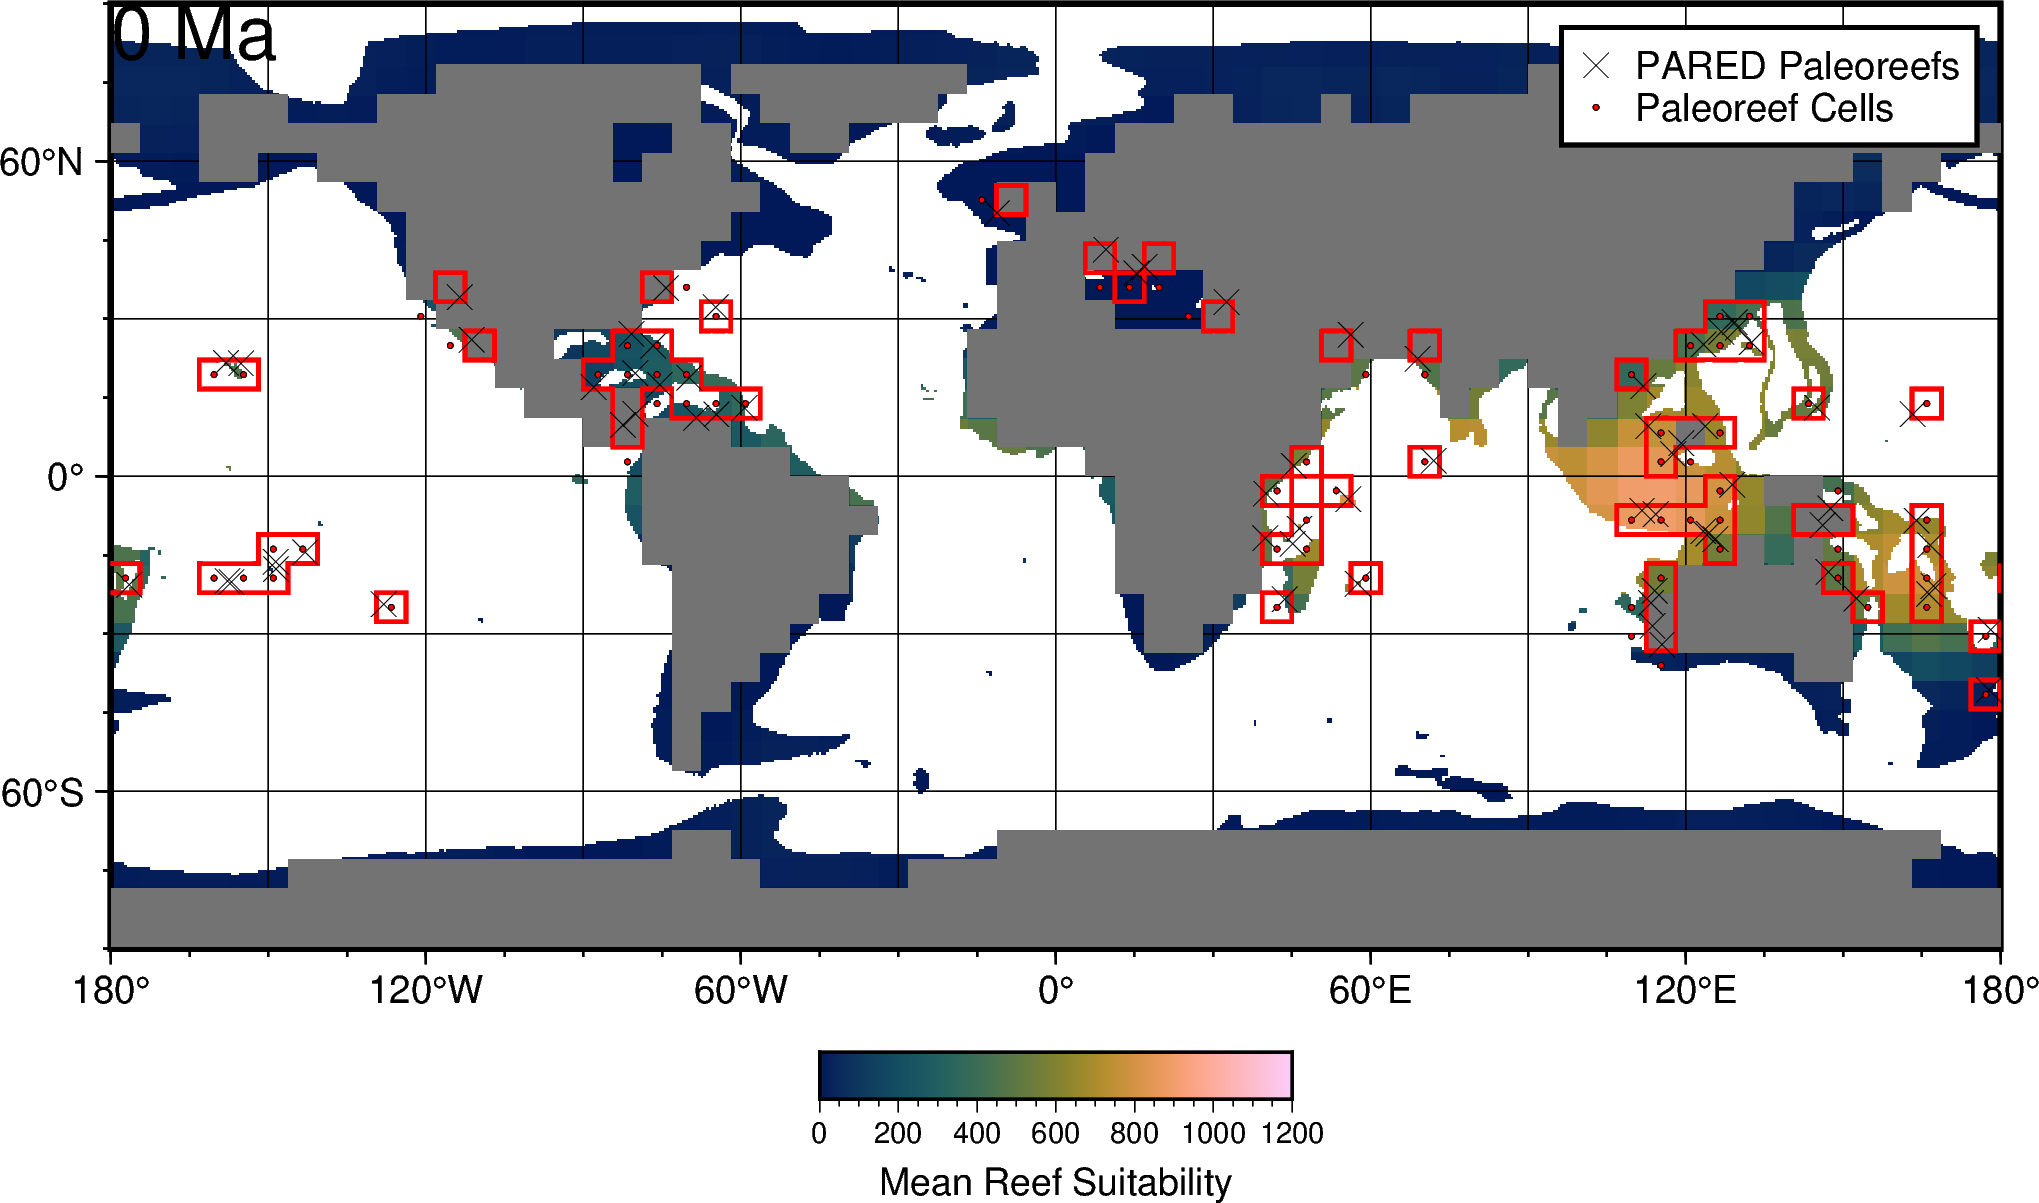

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


No valid subset found at 36.5625, 8.309966087341309
No valid subset found at 47.8125, 19.39009666442871
No valid subset found at 36.5625, 13.849992752075195
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 13.849992752075195
No valid subset found at 19.6875, 47.093719482421875
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 19.6875, 47.093719482421875


grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples of the grid increment (0.499305)
grdimage [WARNING]: Current region (-R) setting in longitude is -180 to 180
grdimage [WARNING]: Adjusted region (-R) setting in longitude is -180 to 180
grdimage [INFORMATION]: Spherical approximation used
g

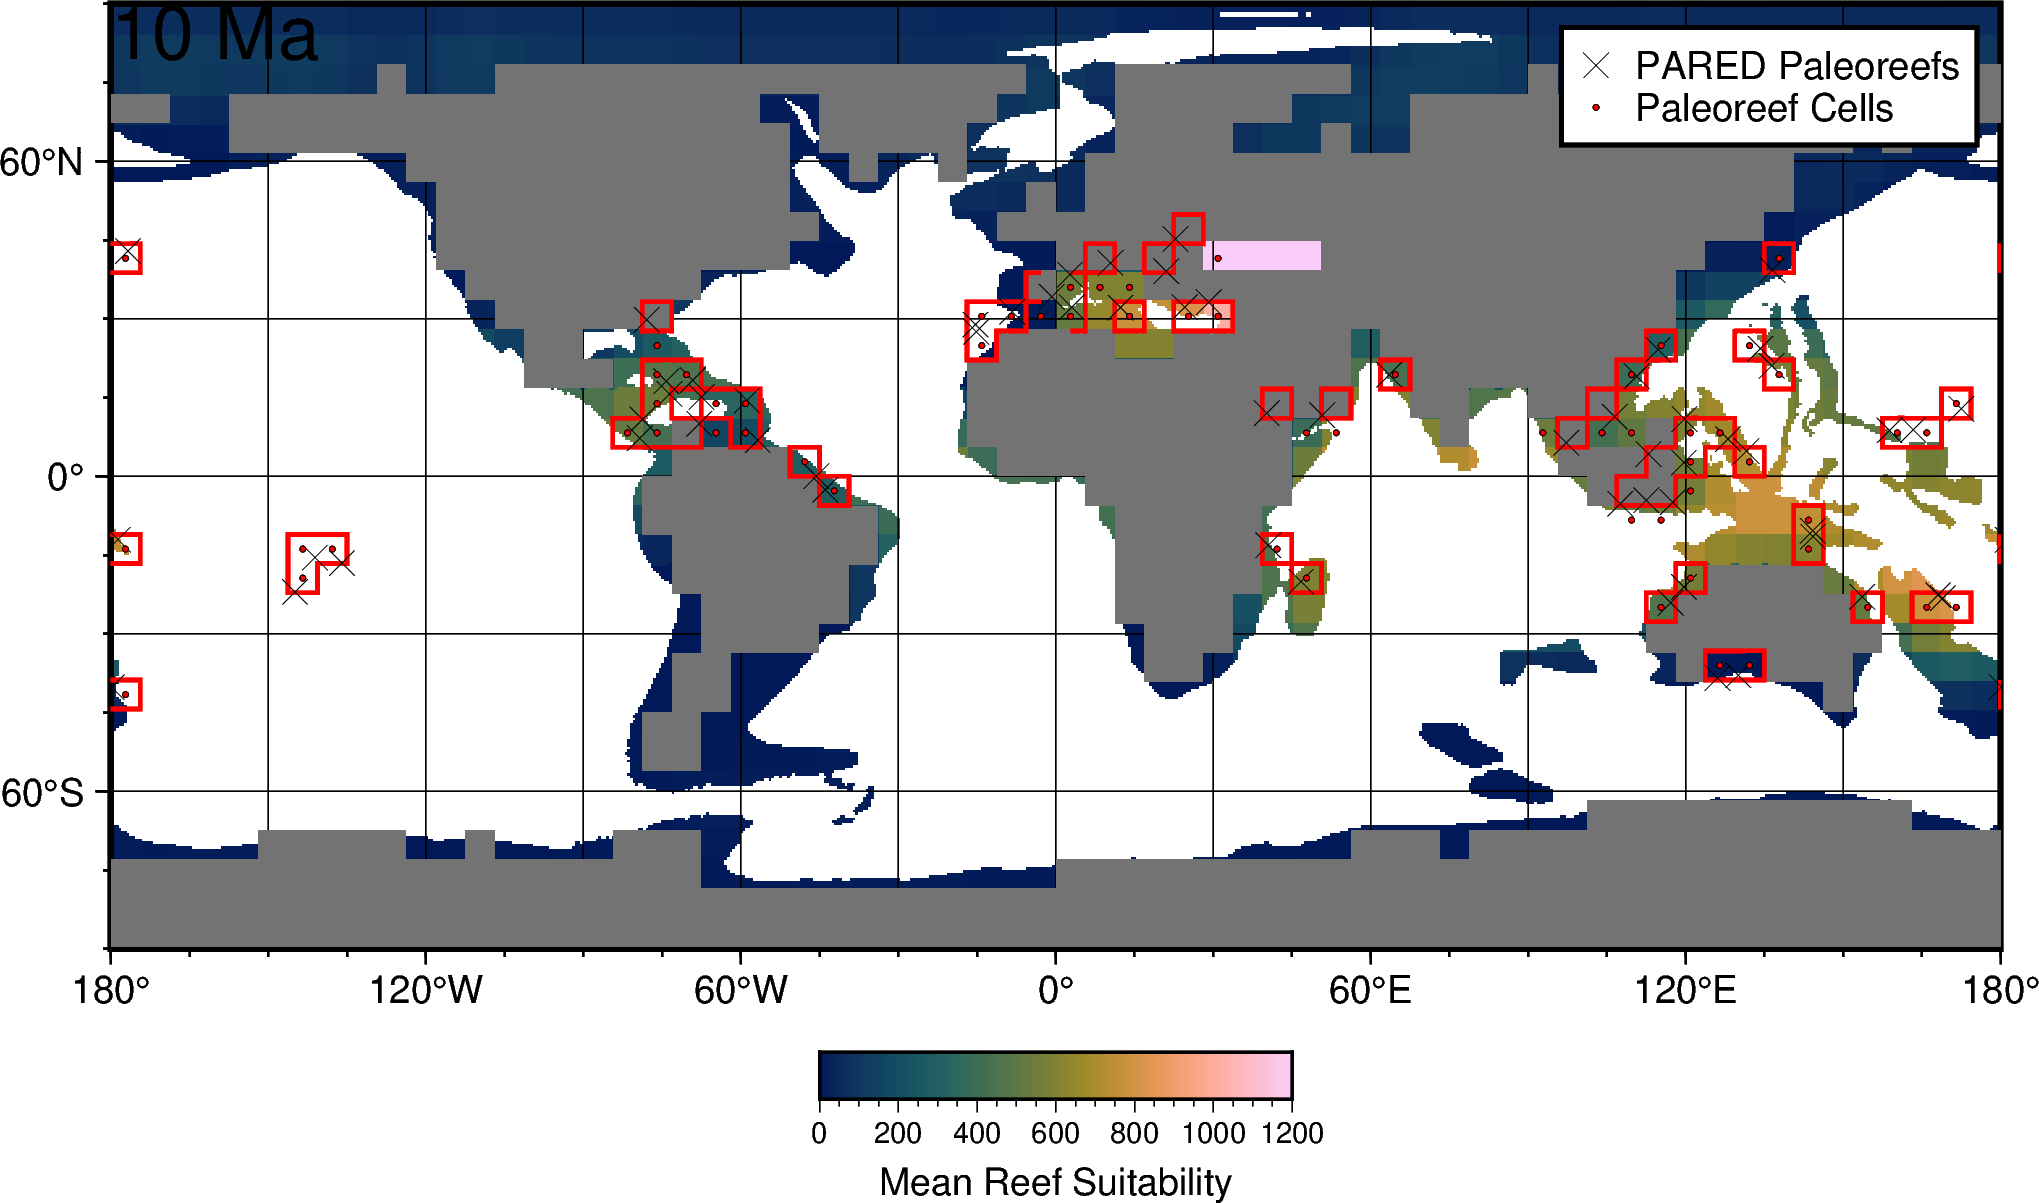

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

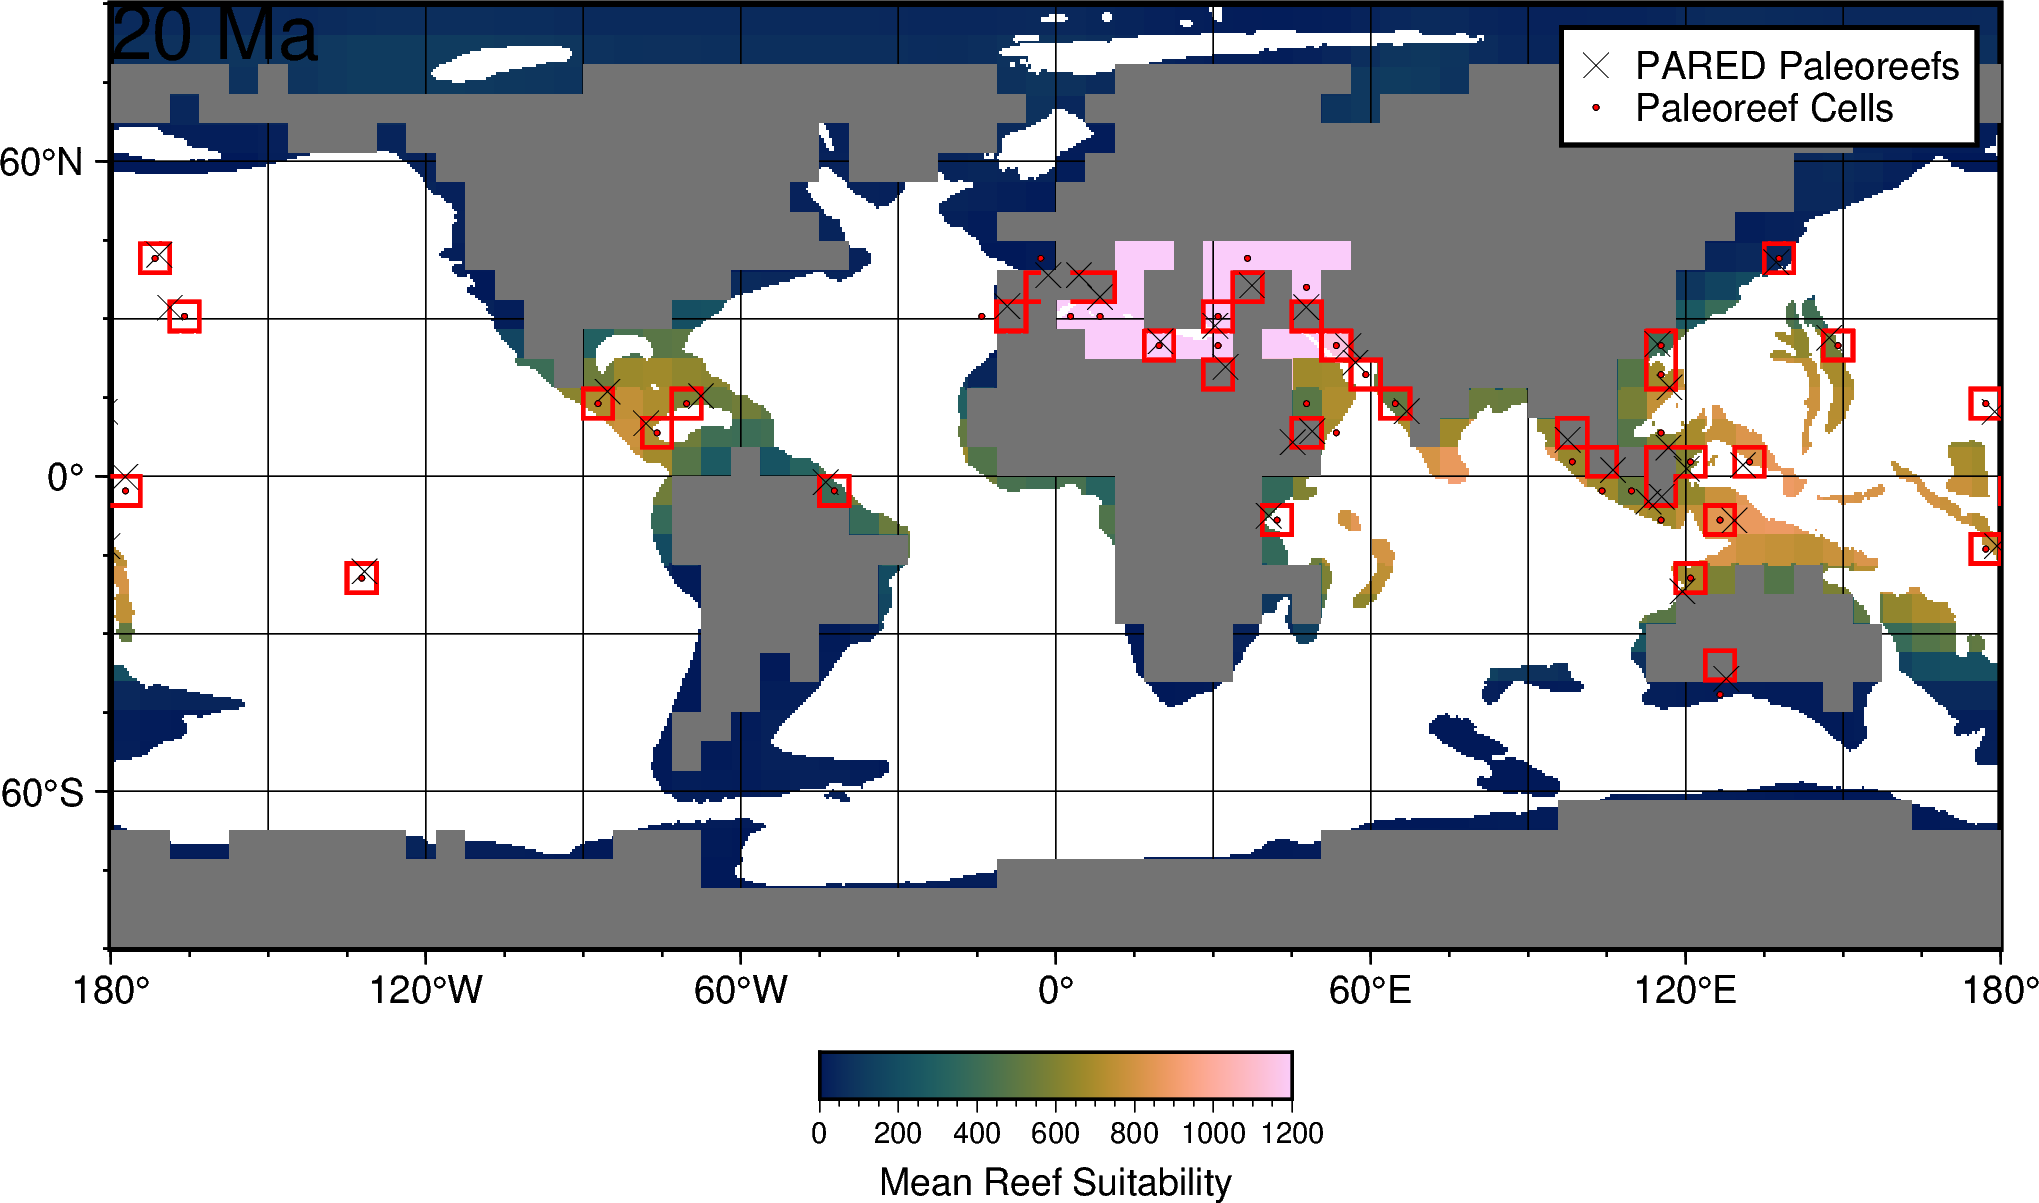

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

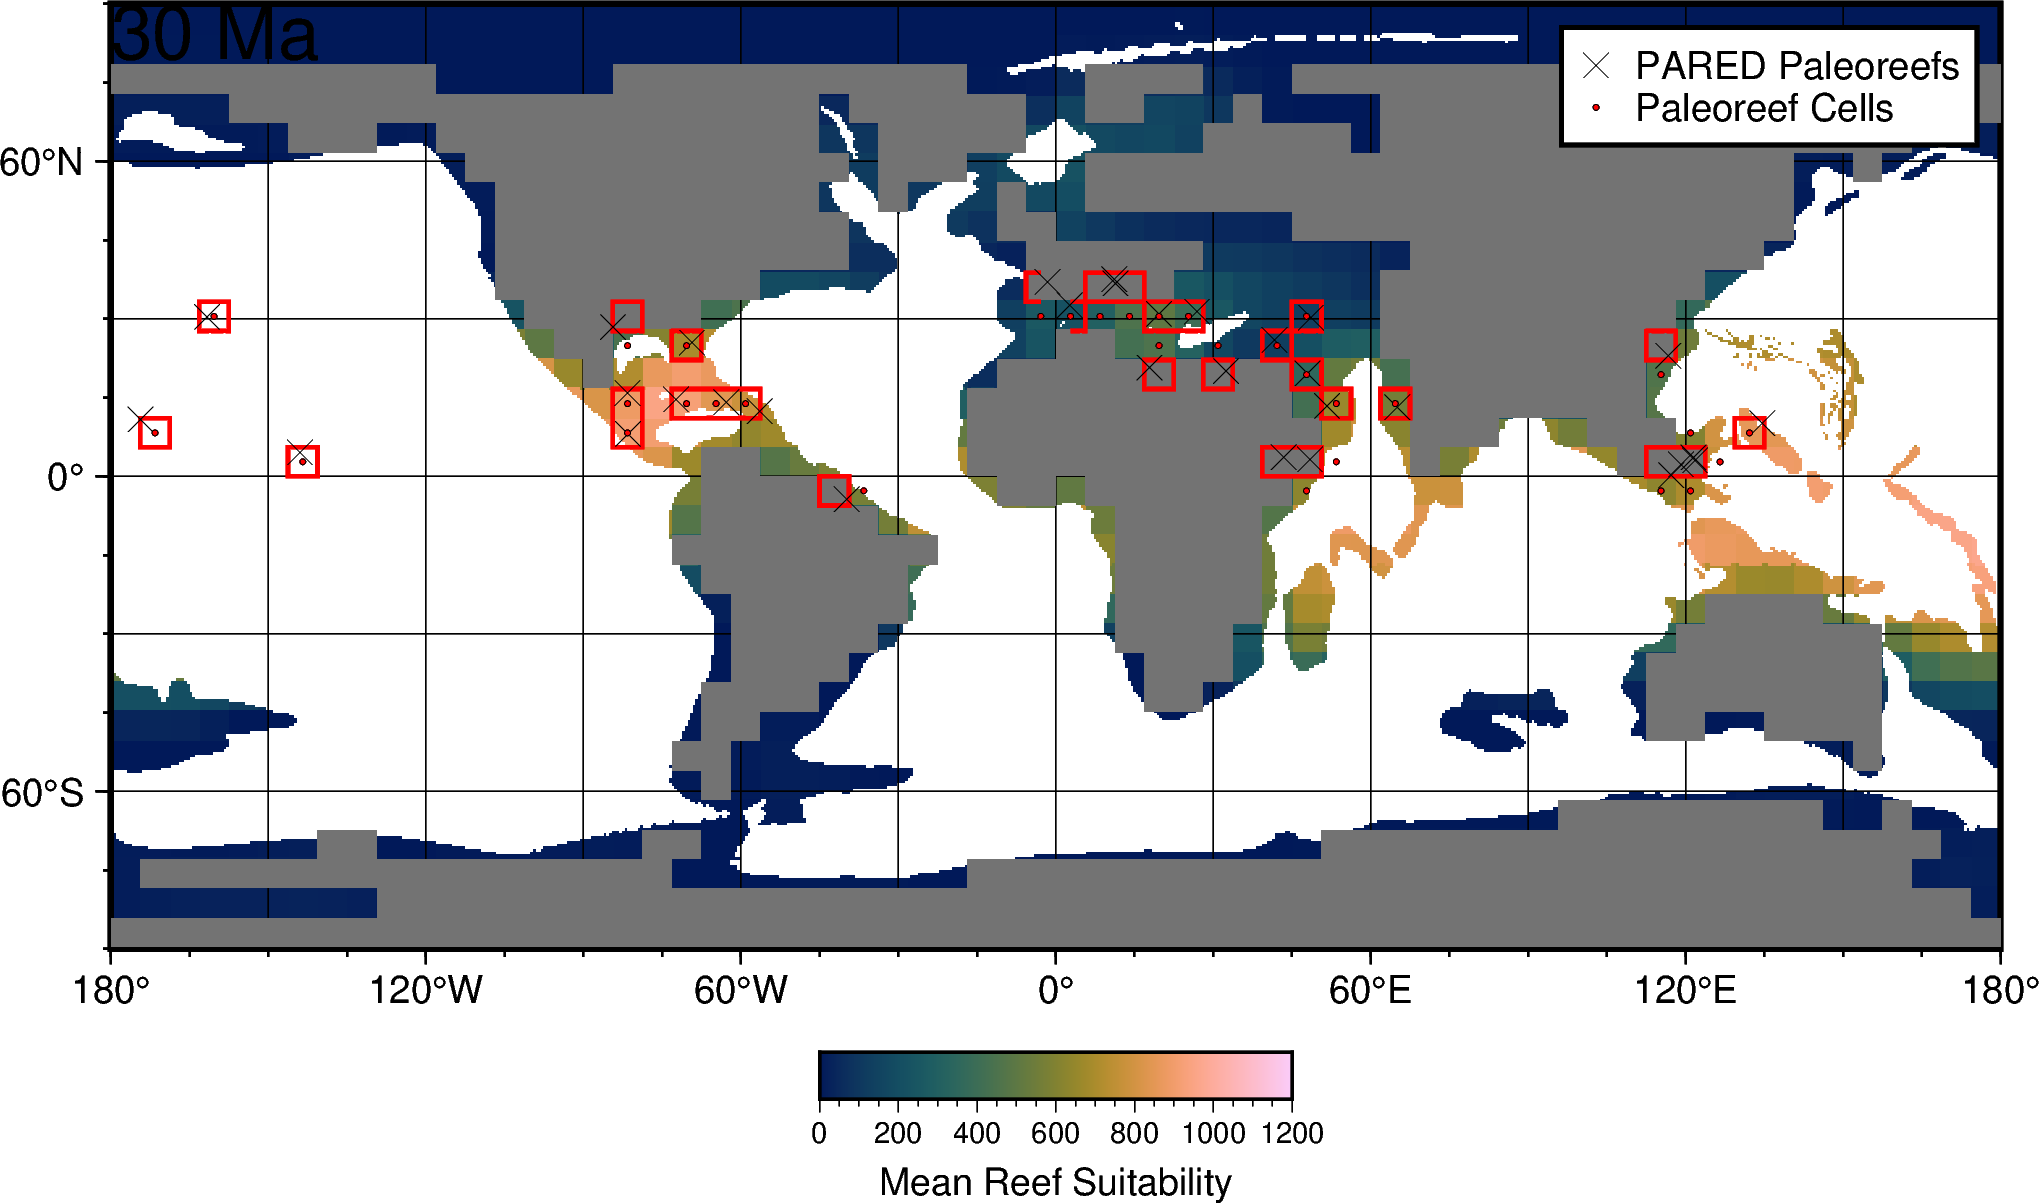

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

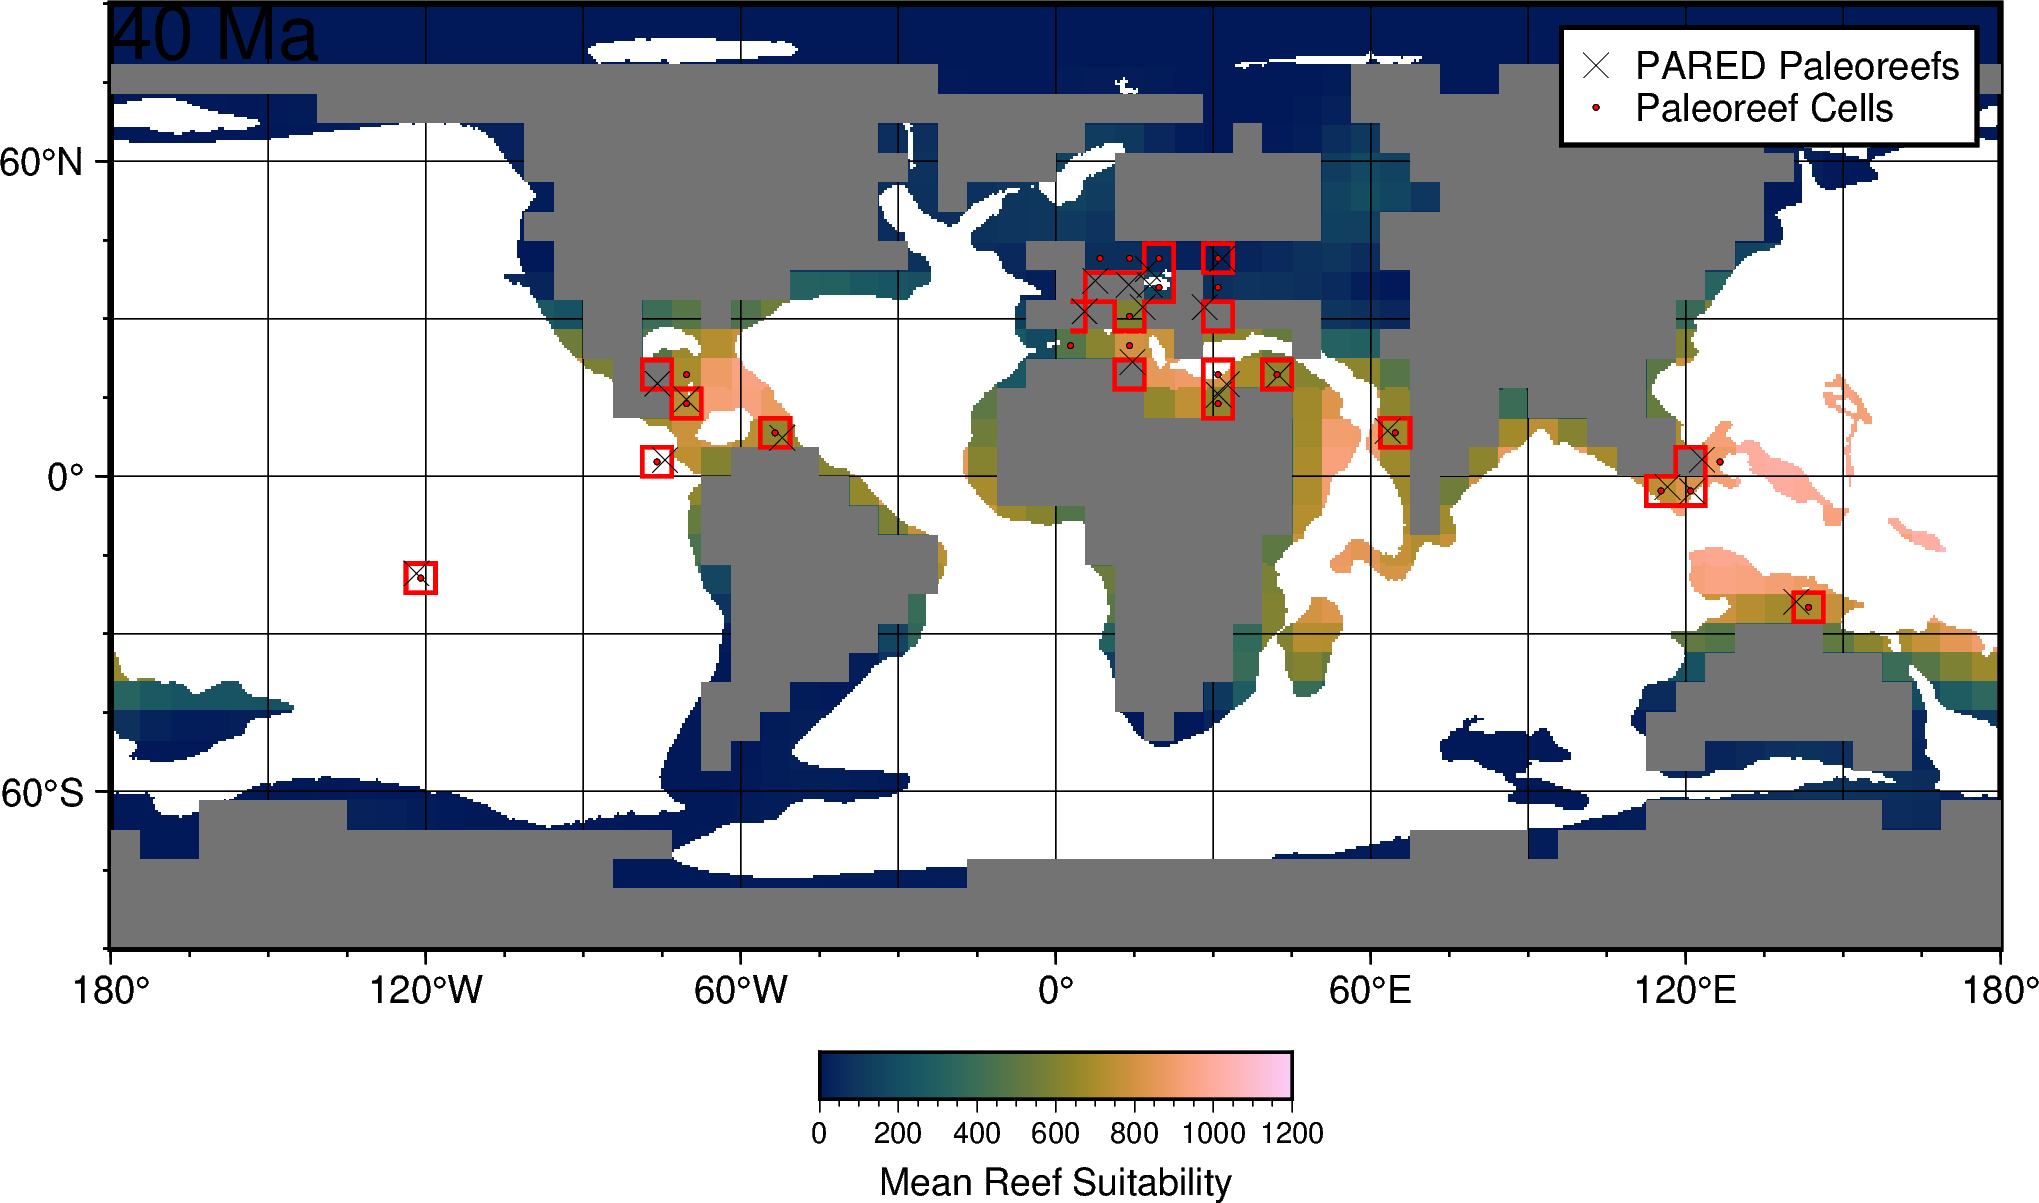

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

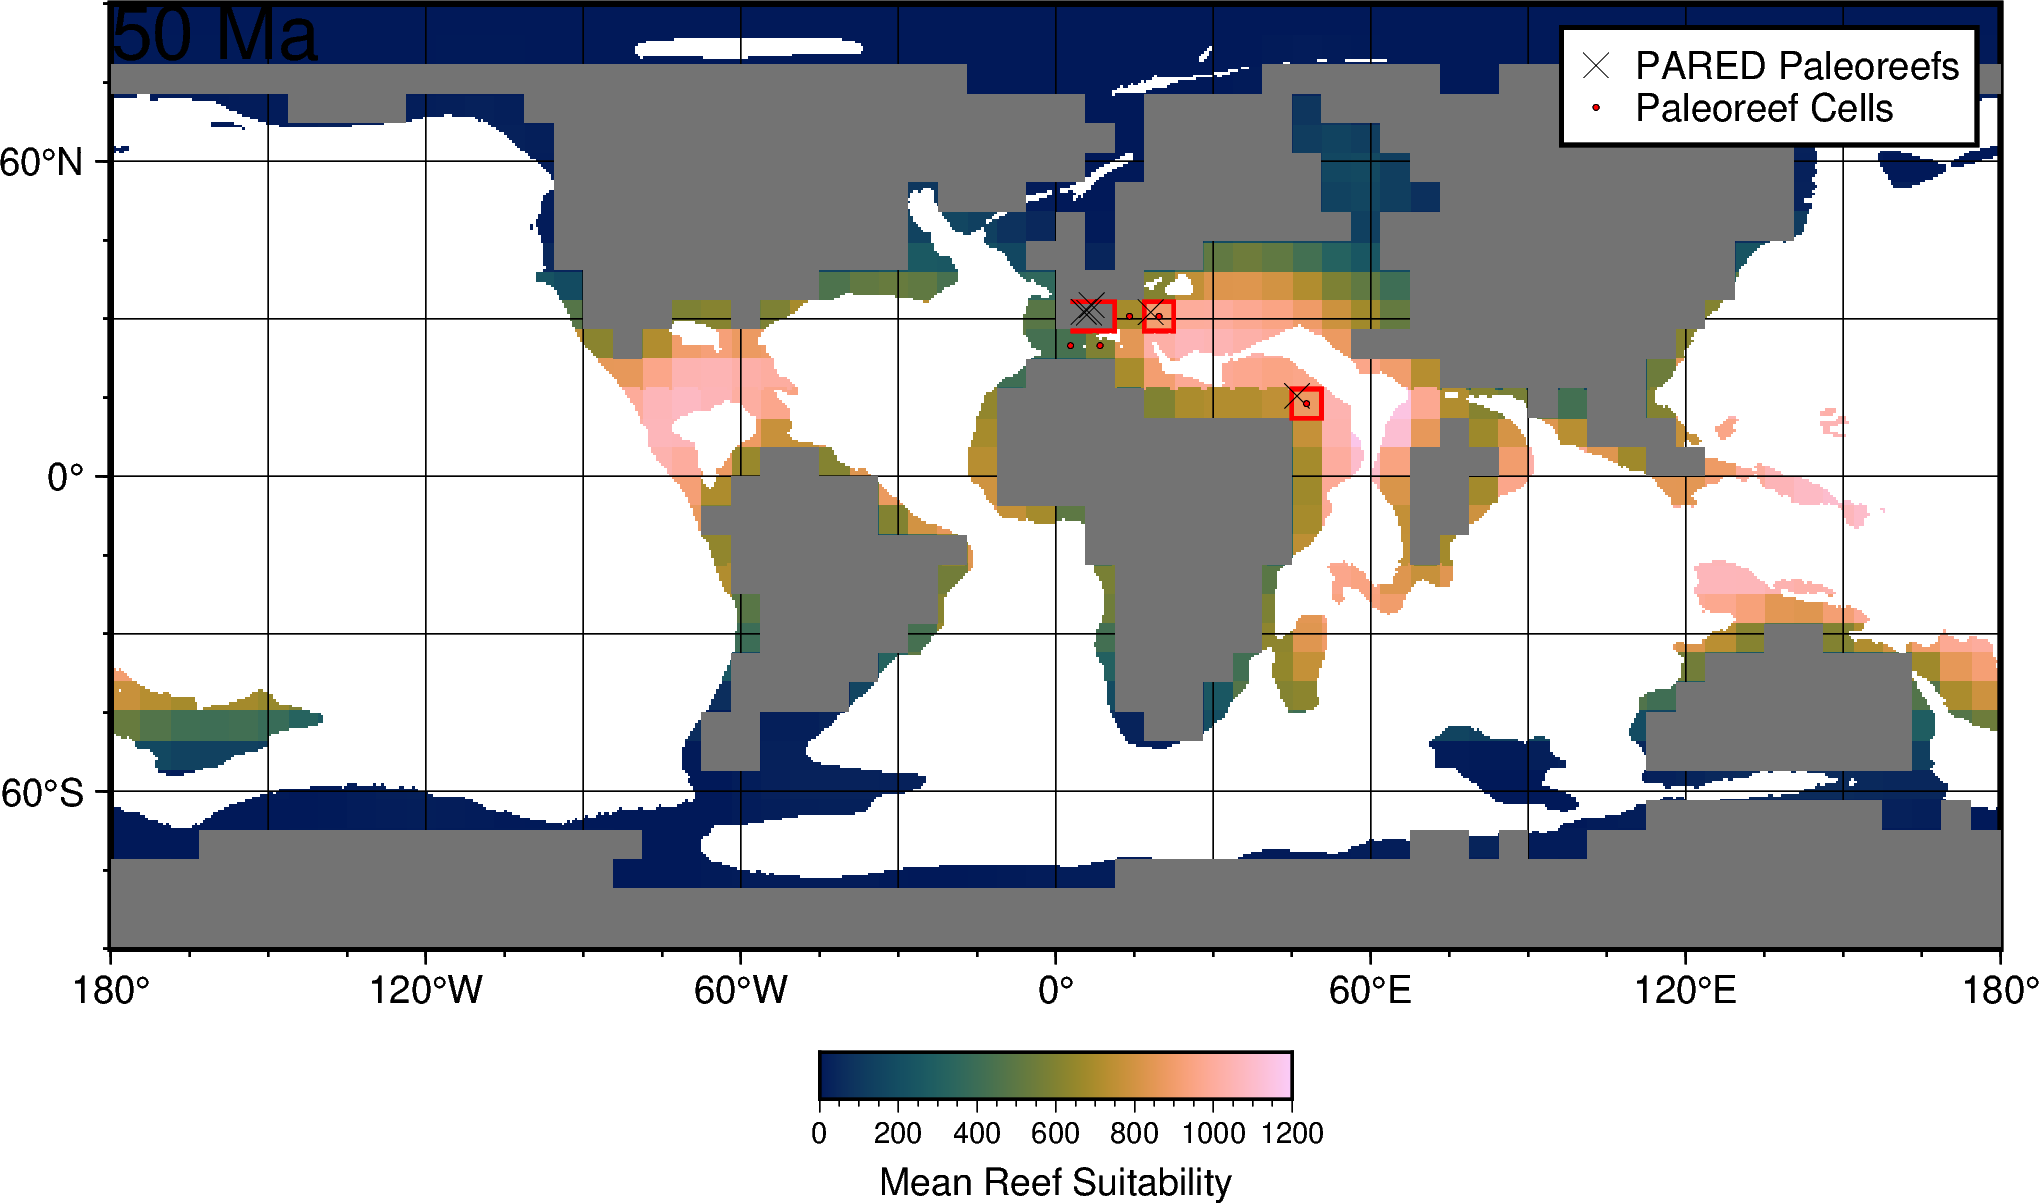

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


No valid subset found at 351.5625, 58.17909240722656


grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples of the grid increment (0.499305)
grdimage [WARNING]: Current region (-R) setting in longitude is -180 to 180
grdimage [WARNING]: Adjusted region (-R) setting in longitude is -180 to 180
grdimage [INFORMATION]: Spherical approximation used
g

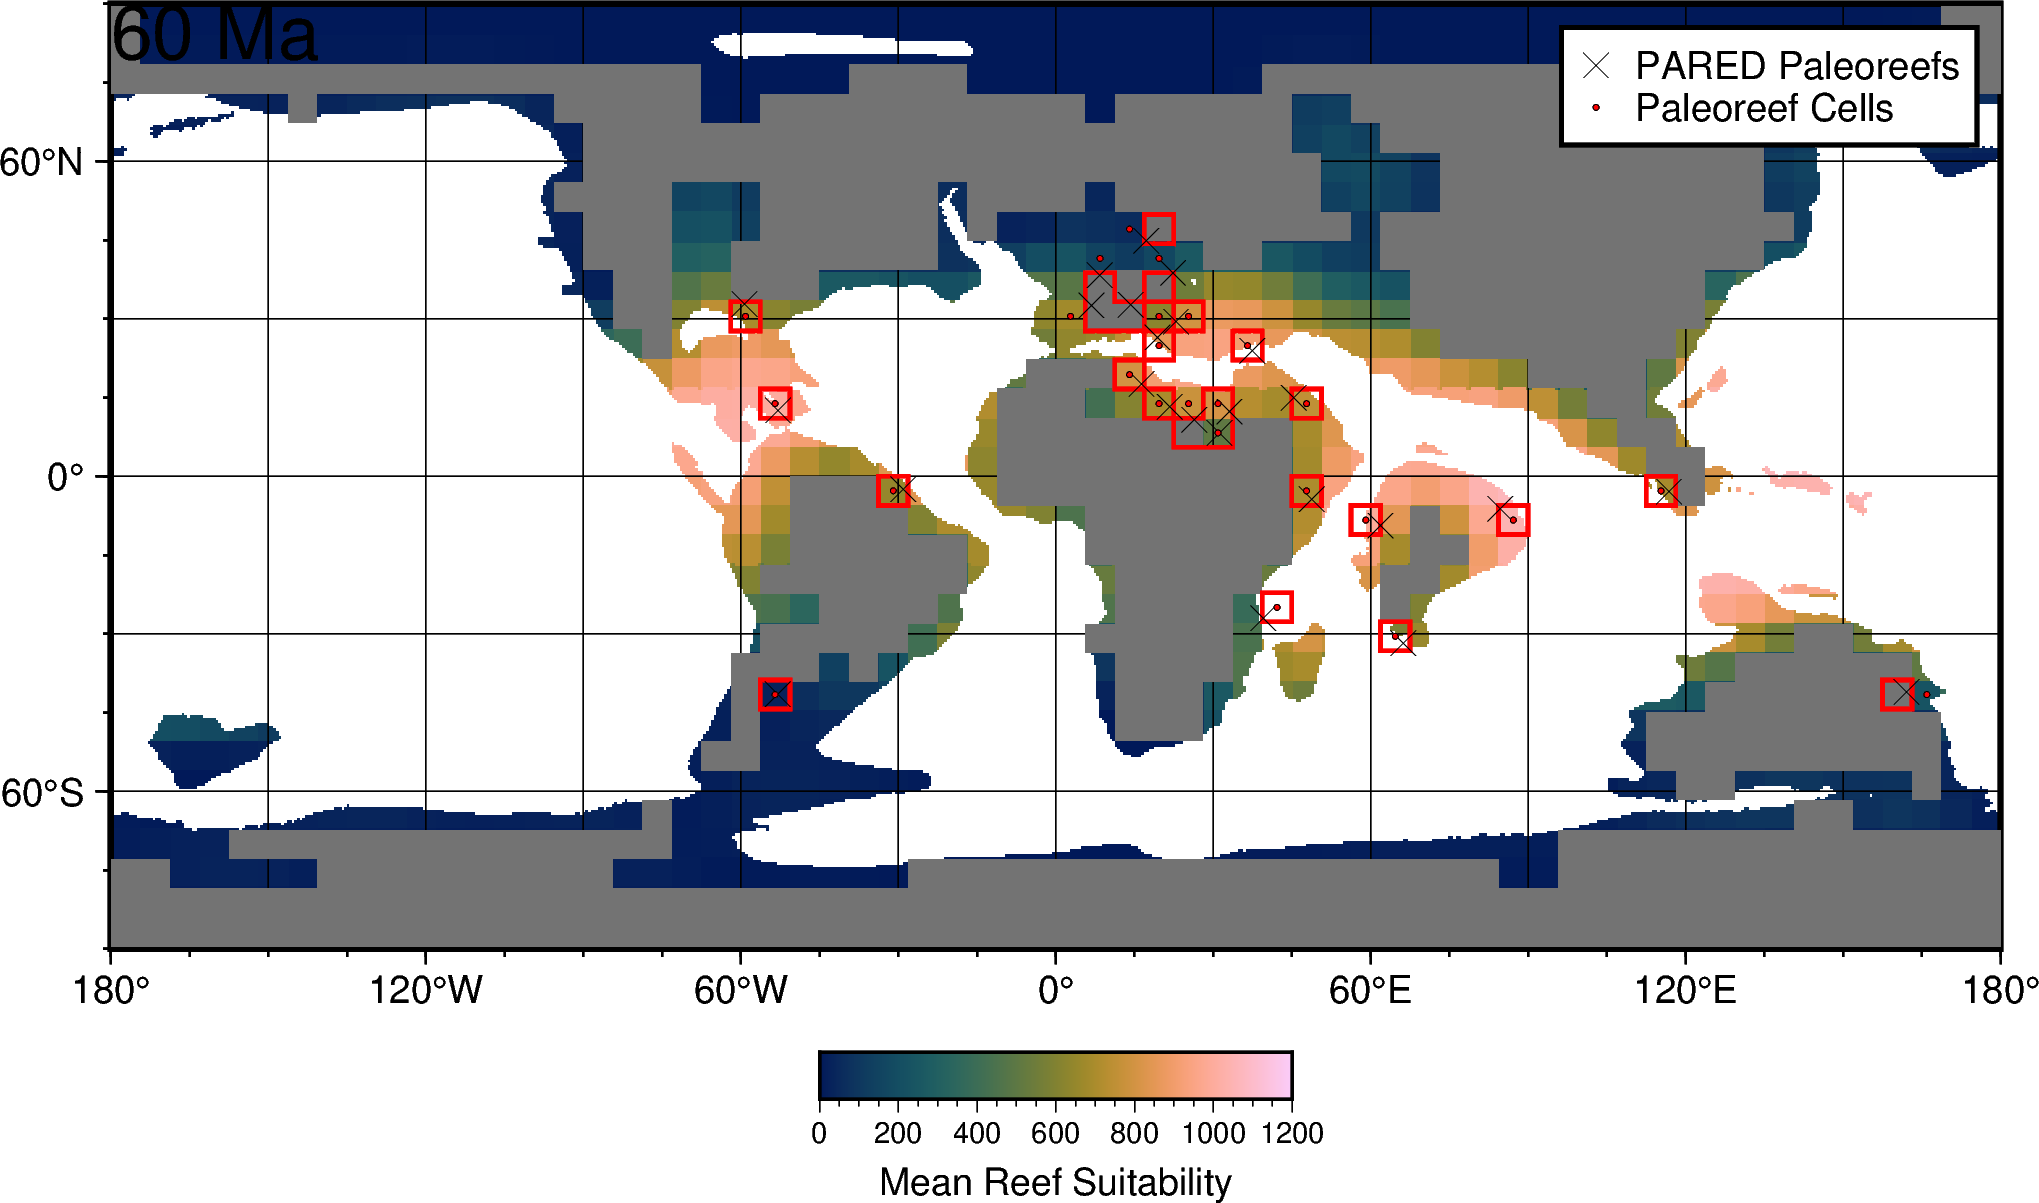

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

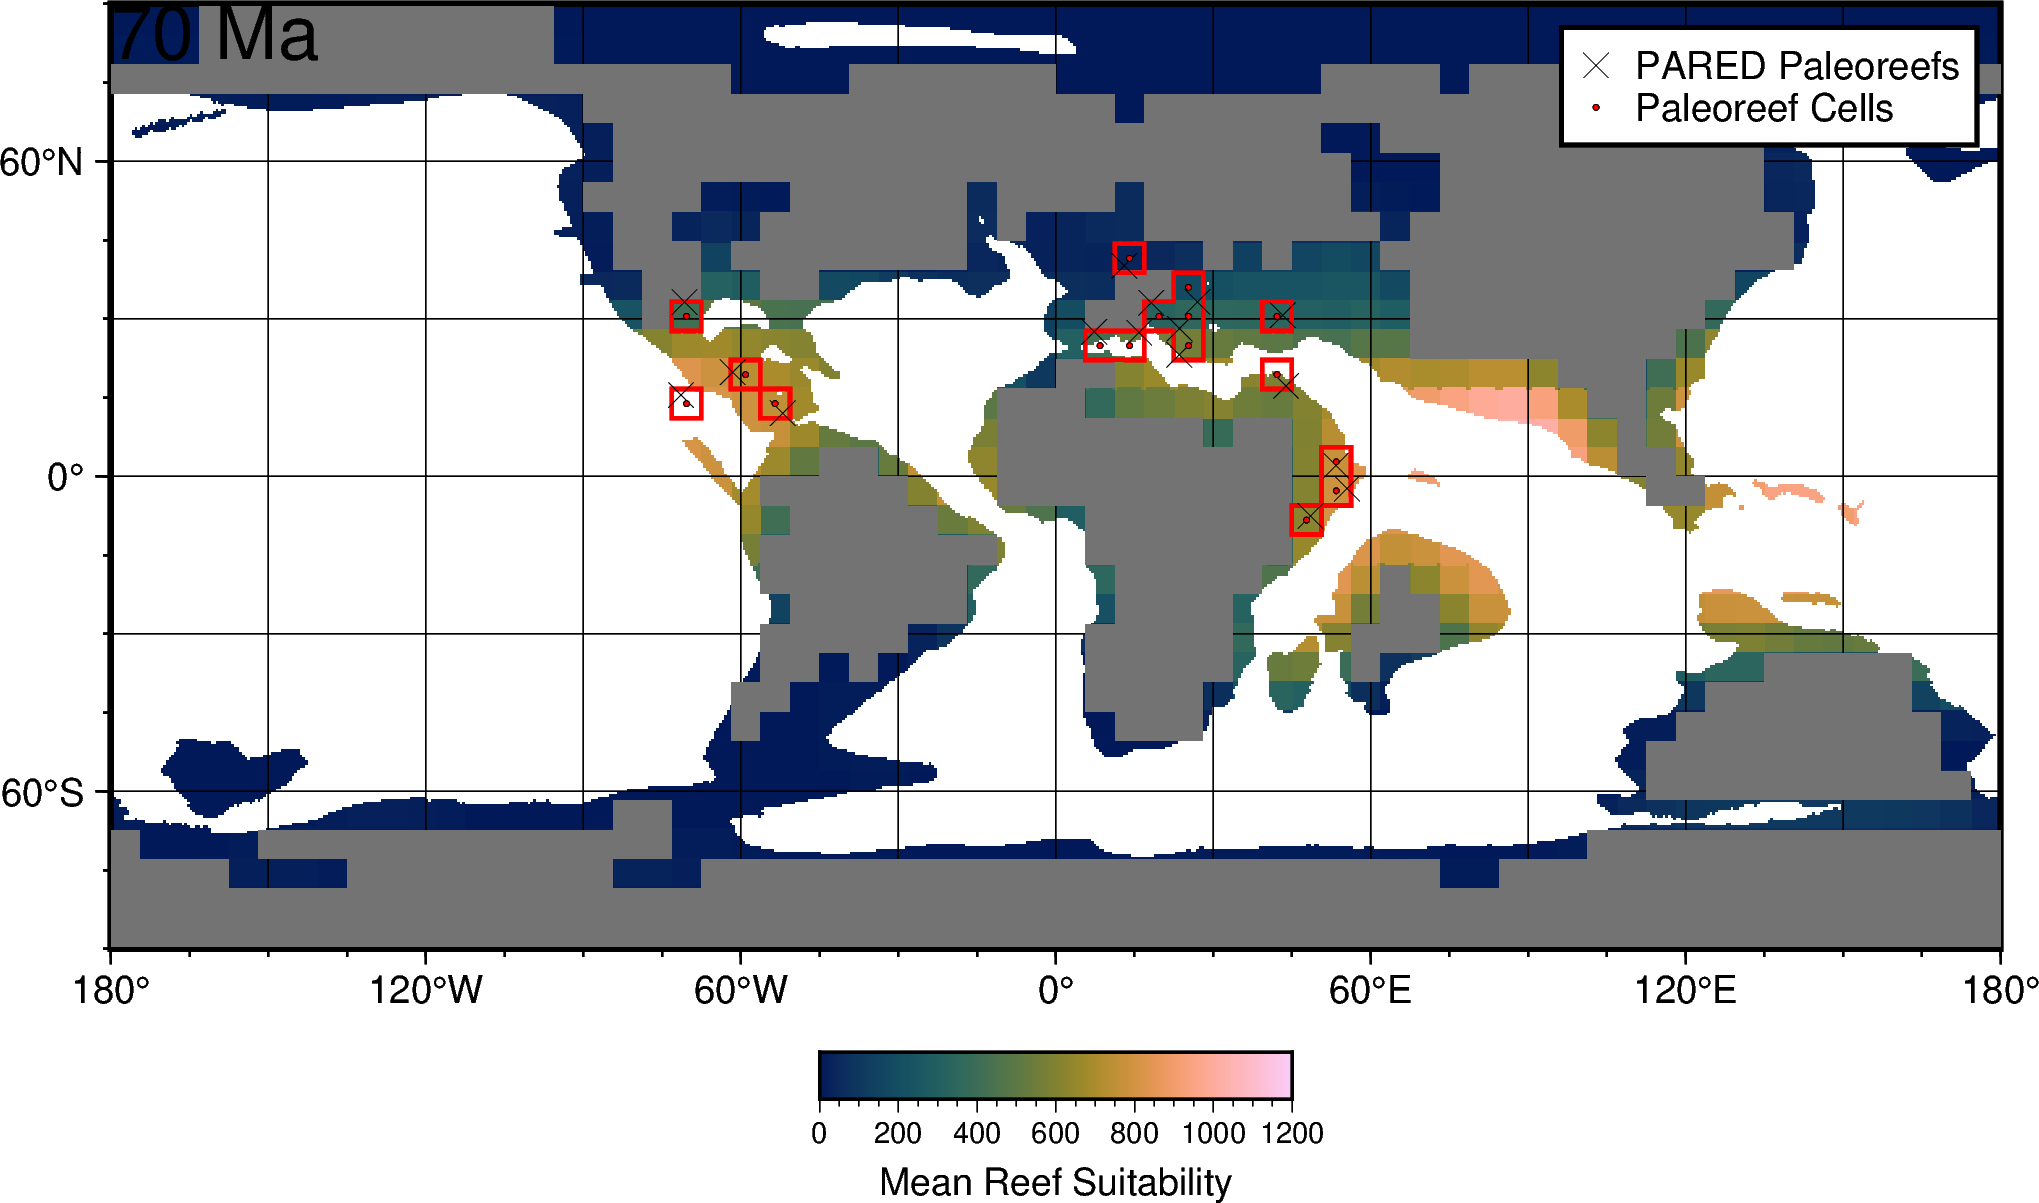

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

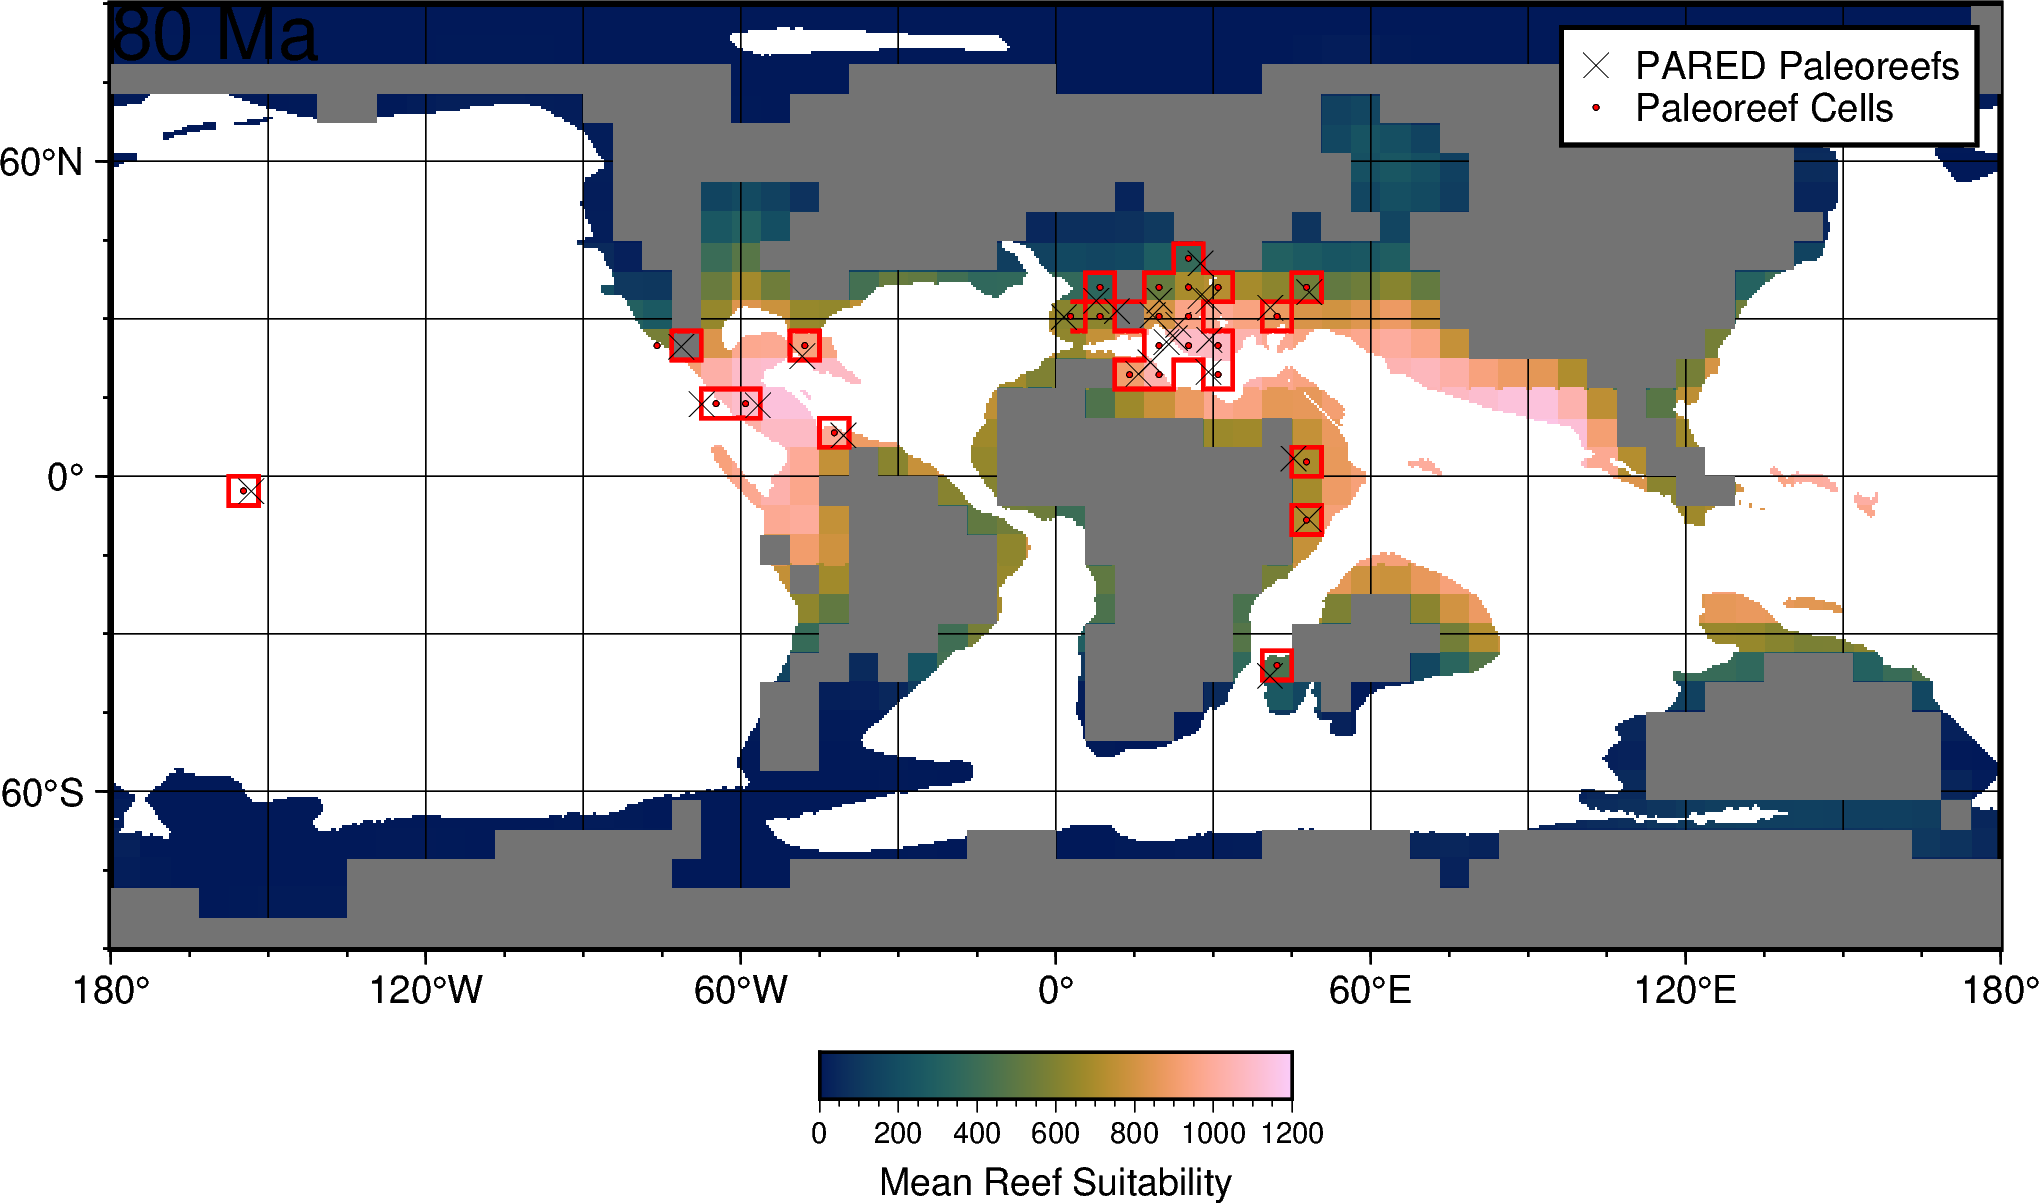

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

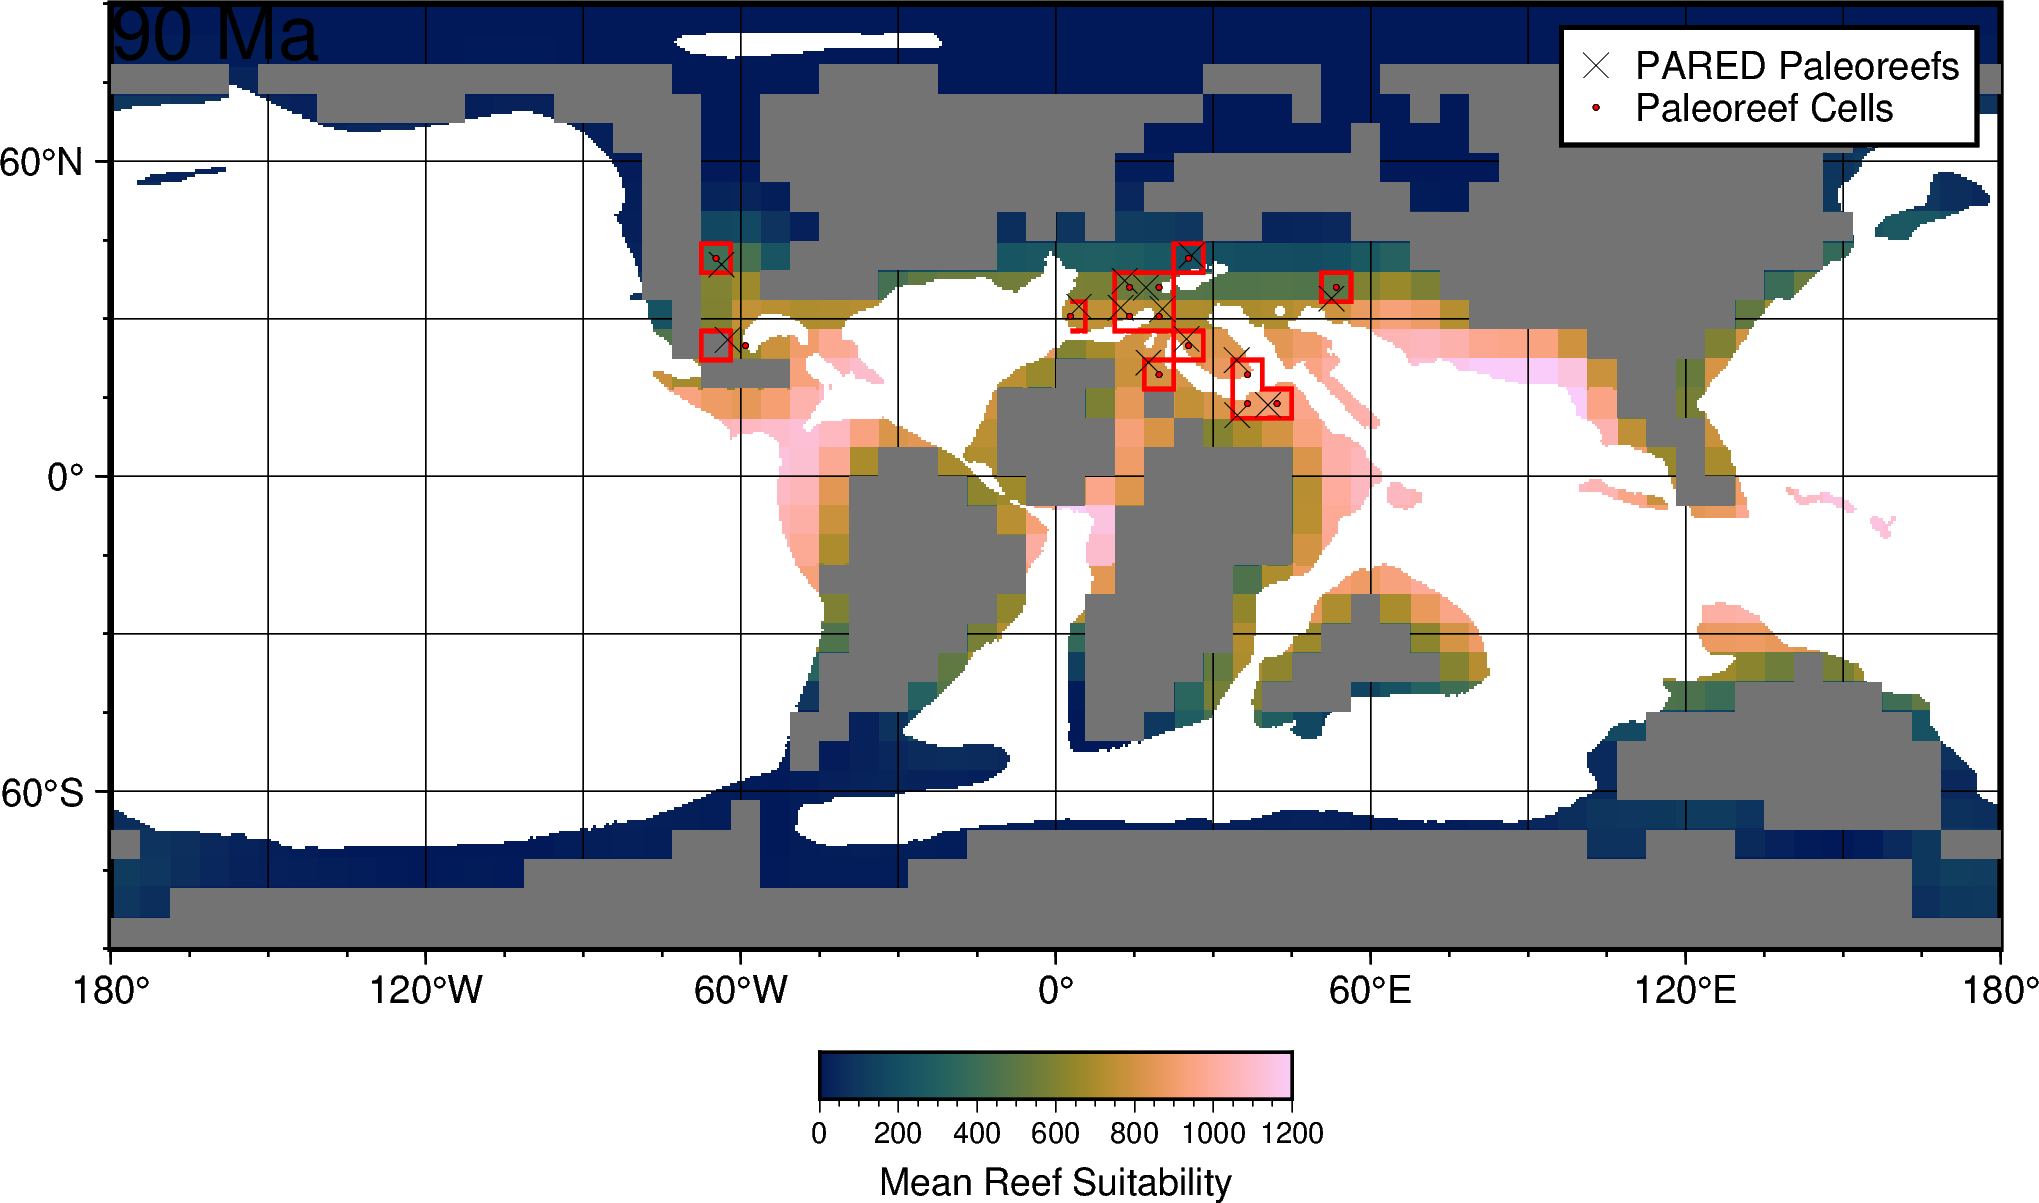

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

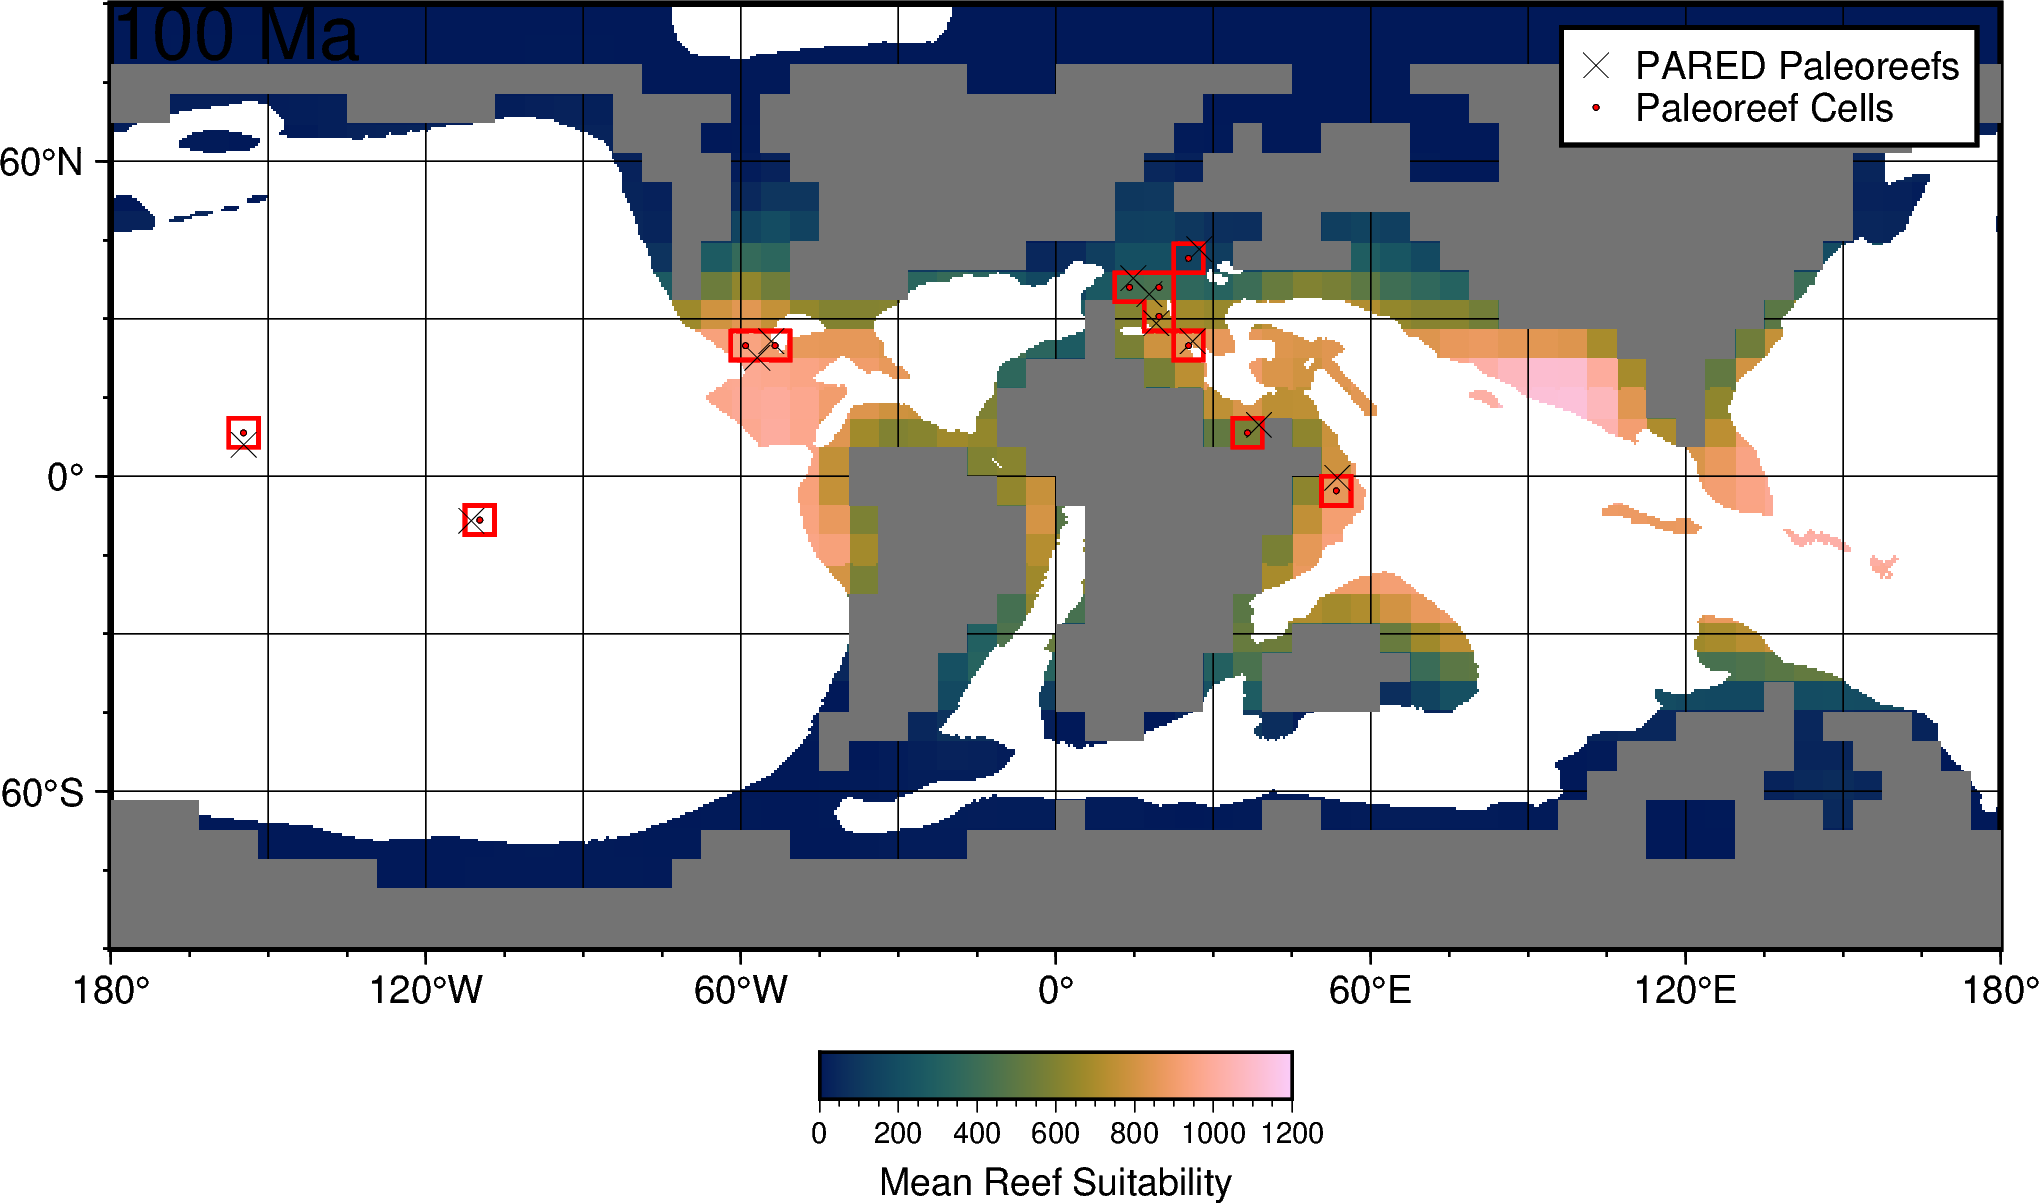

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

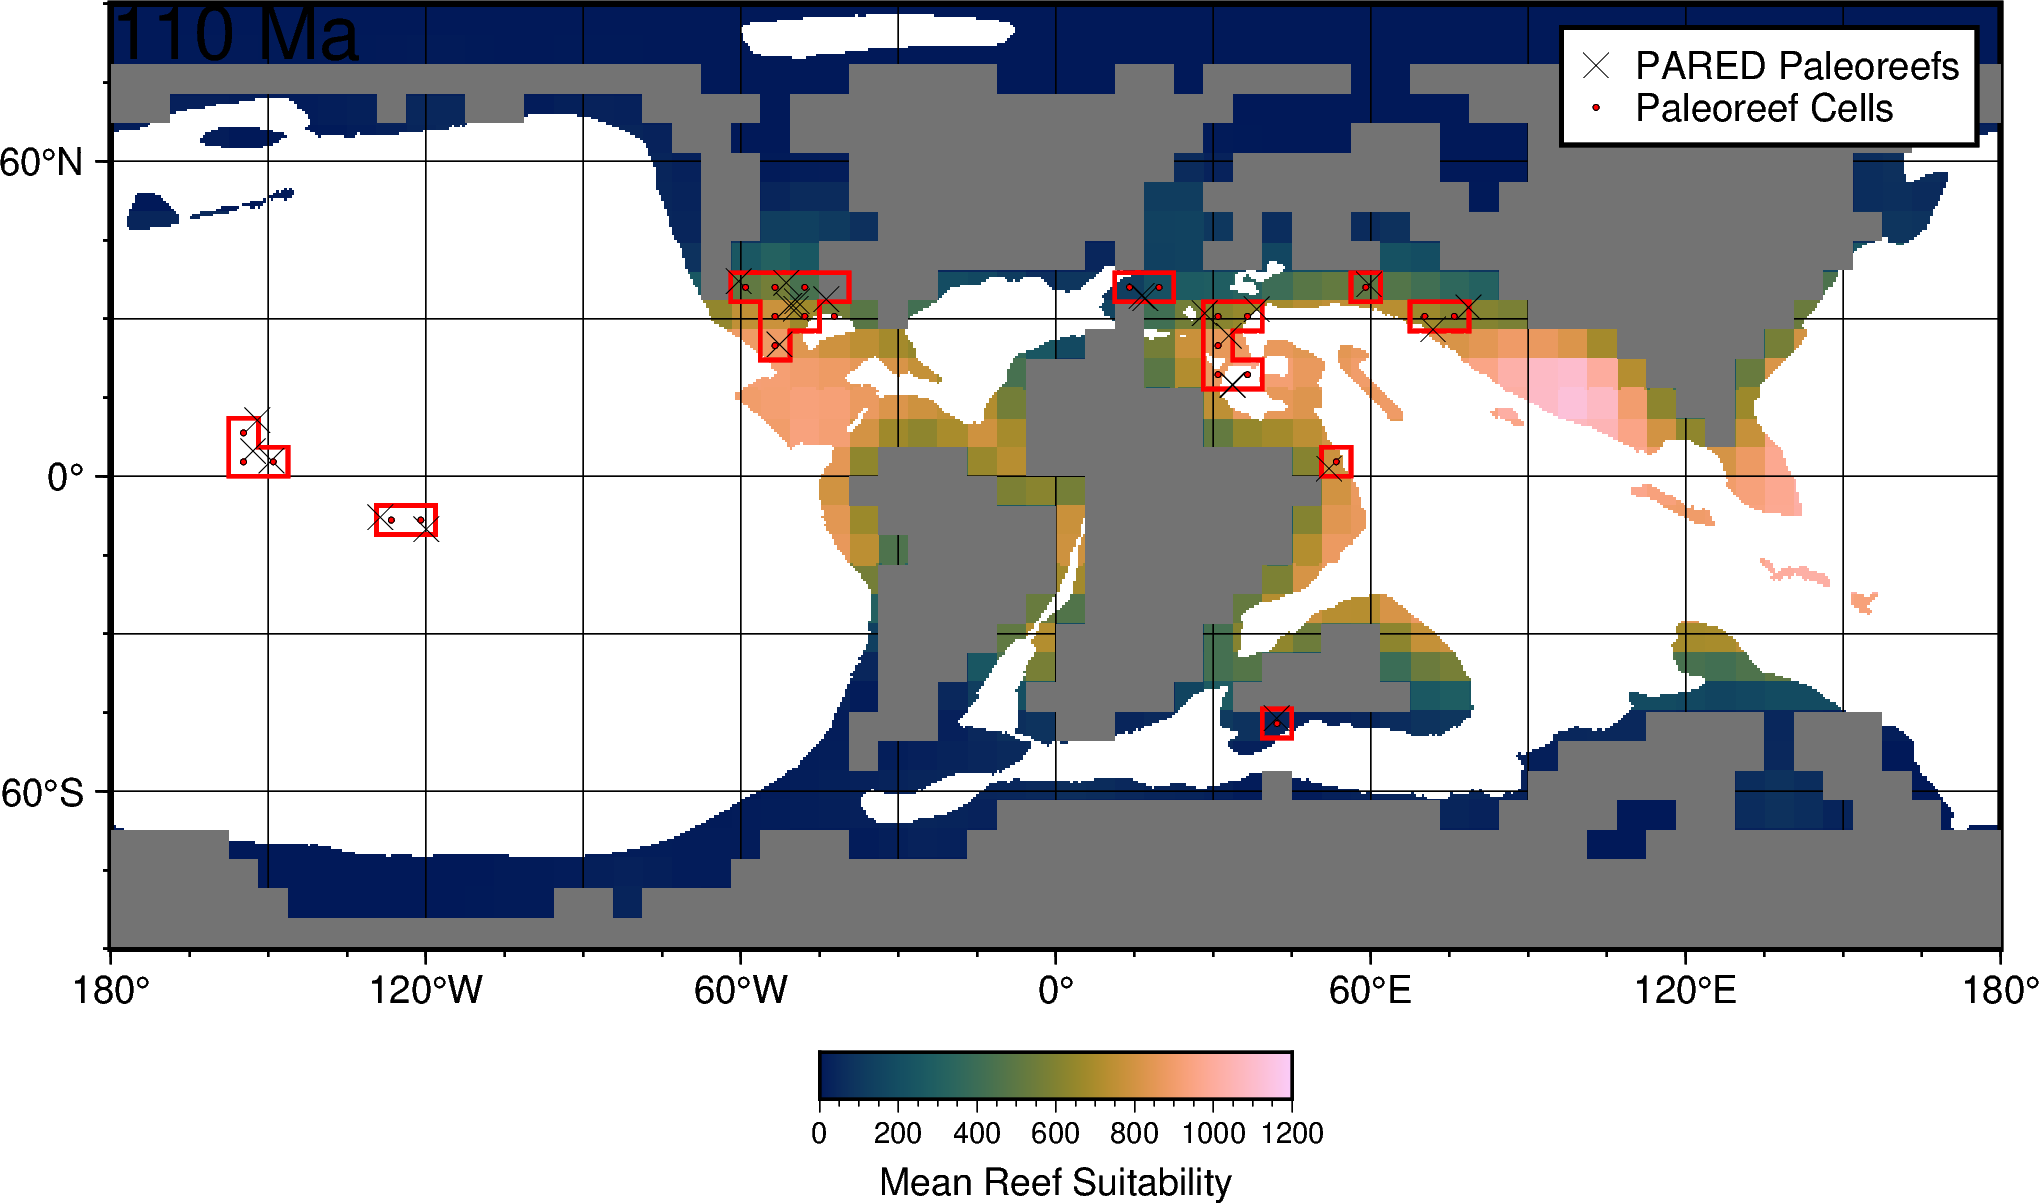

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

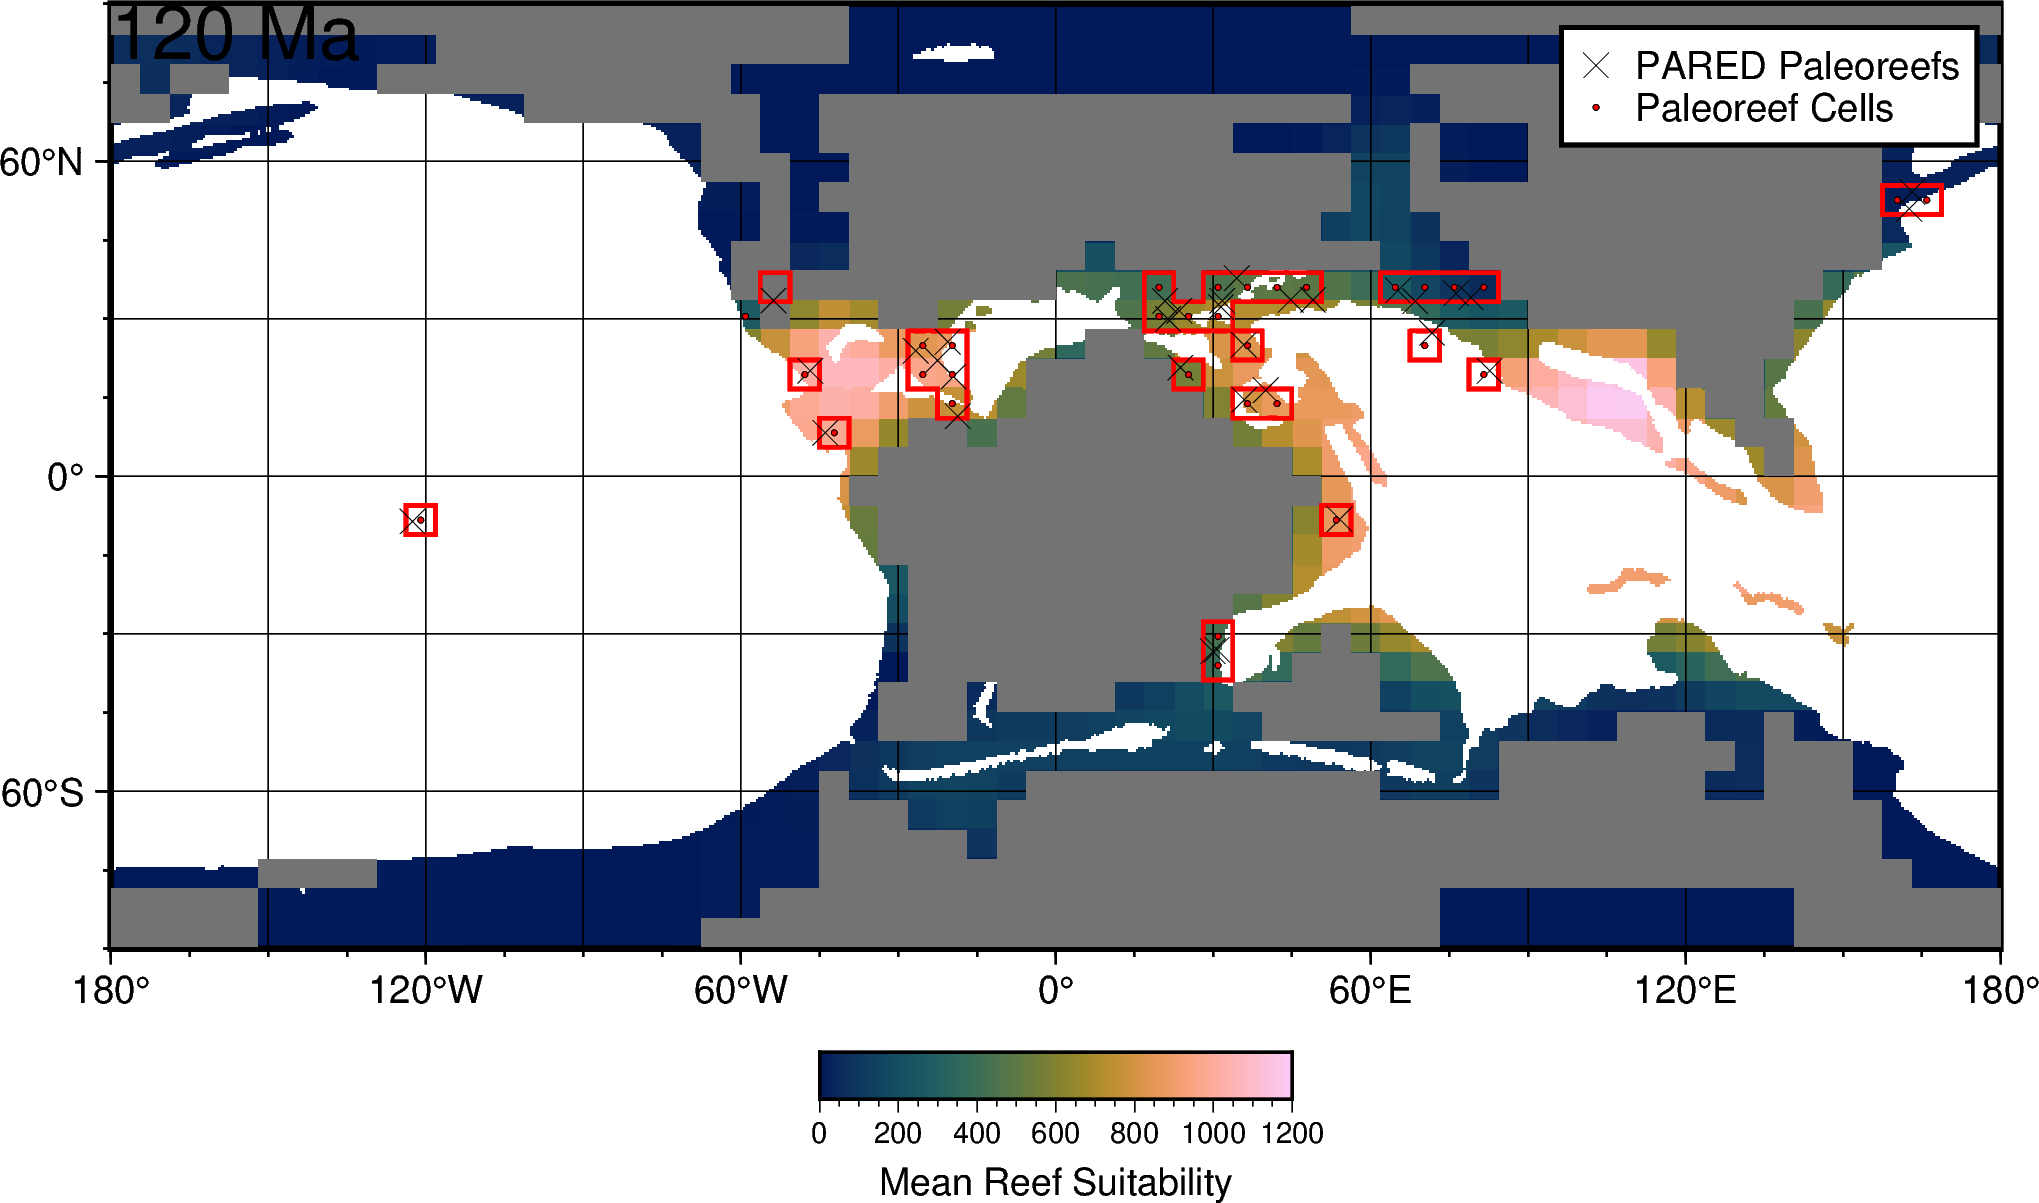

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

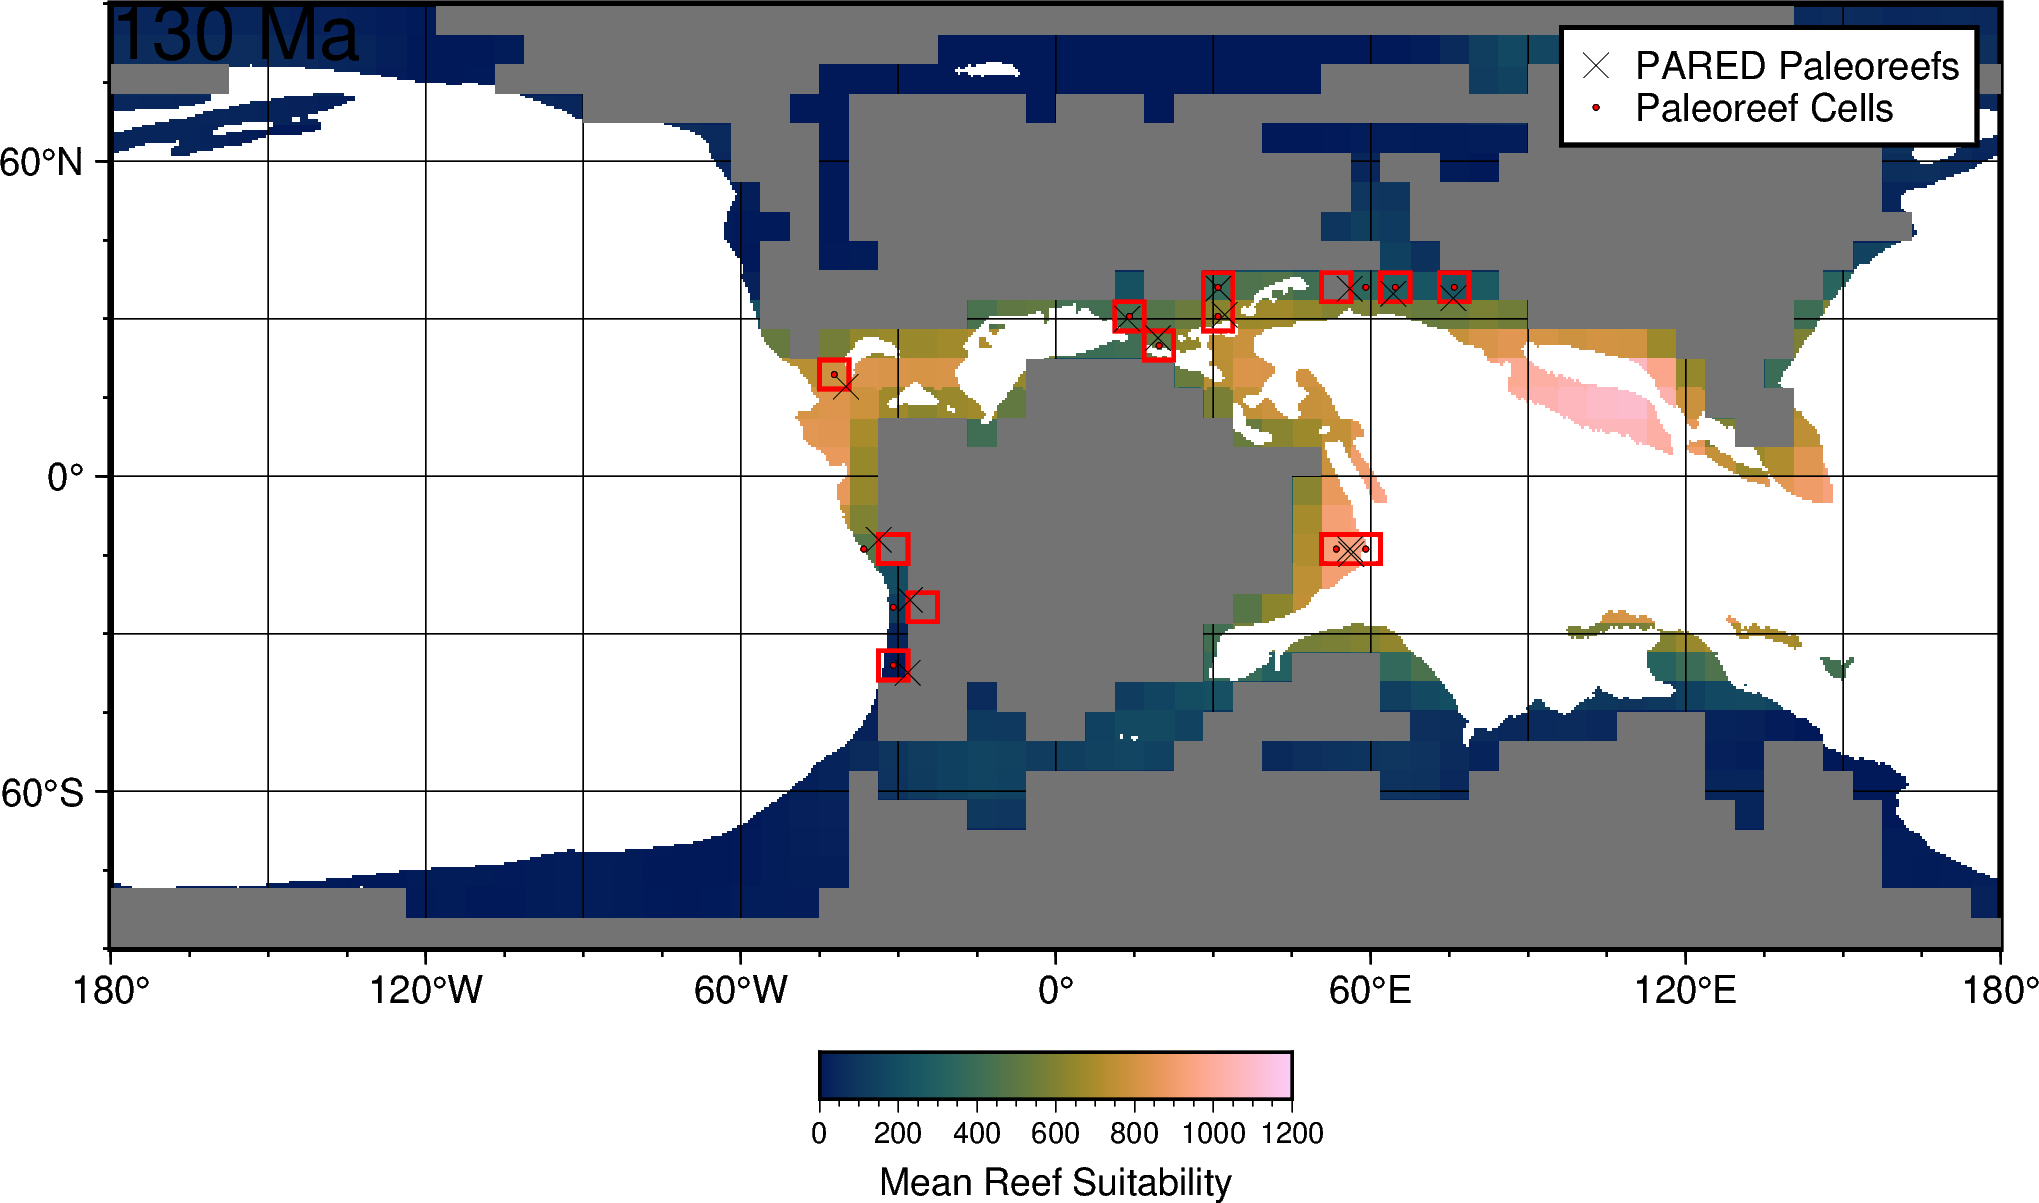

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

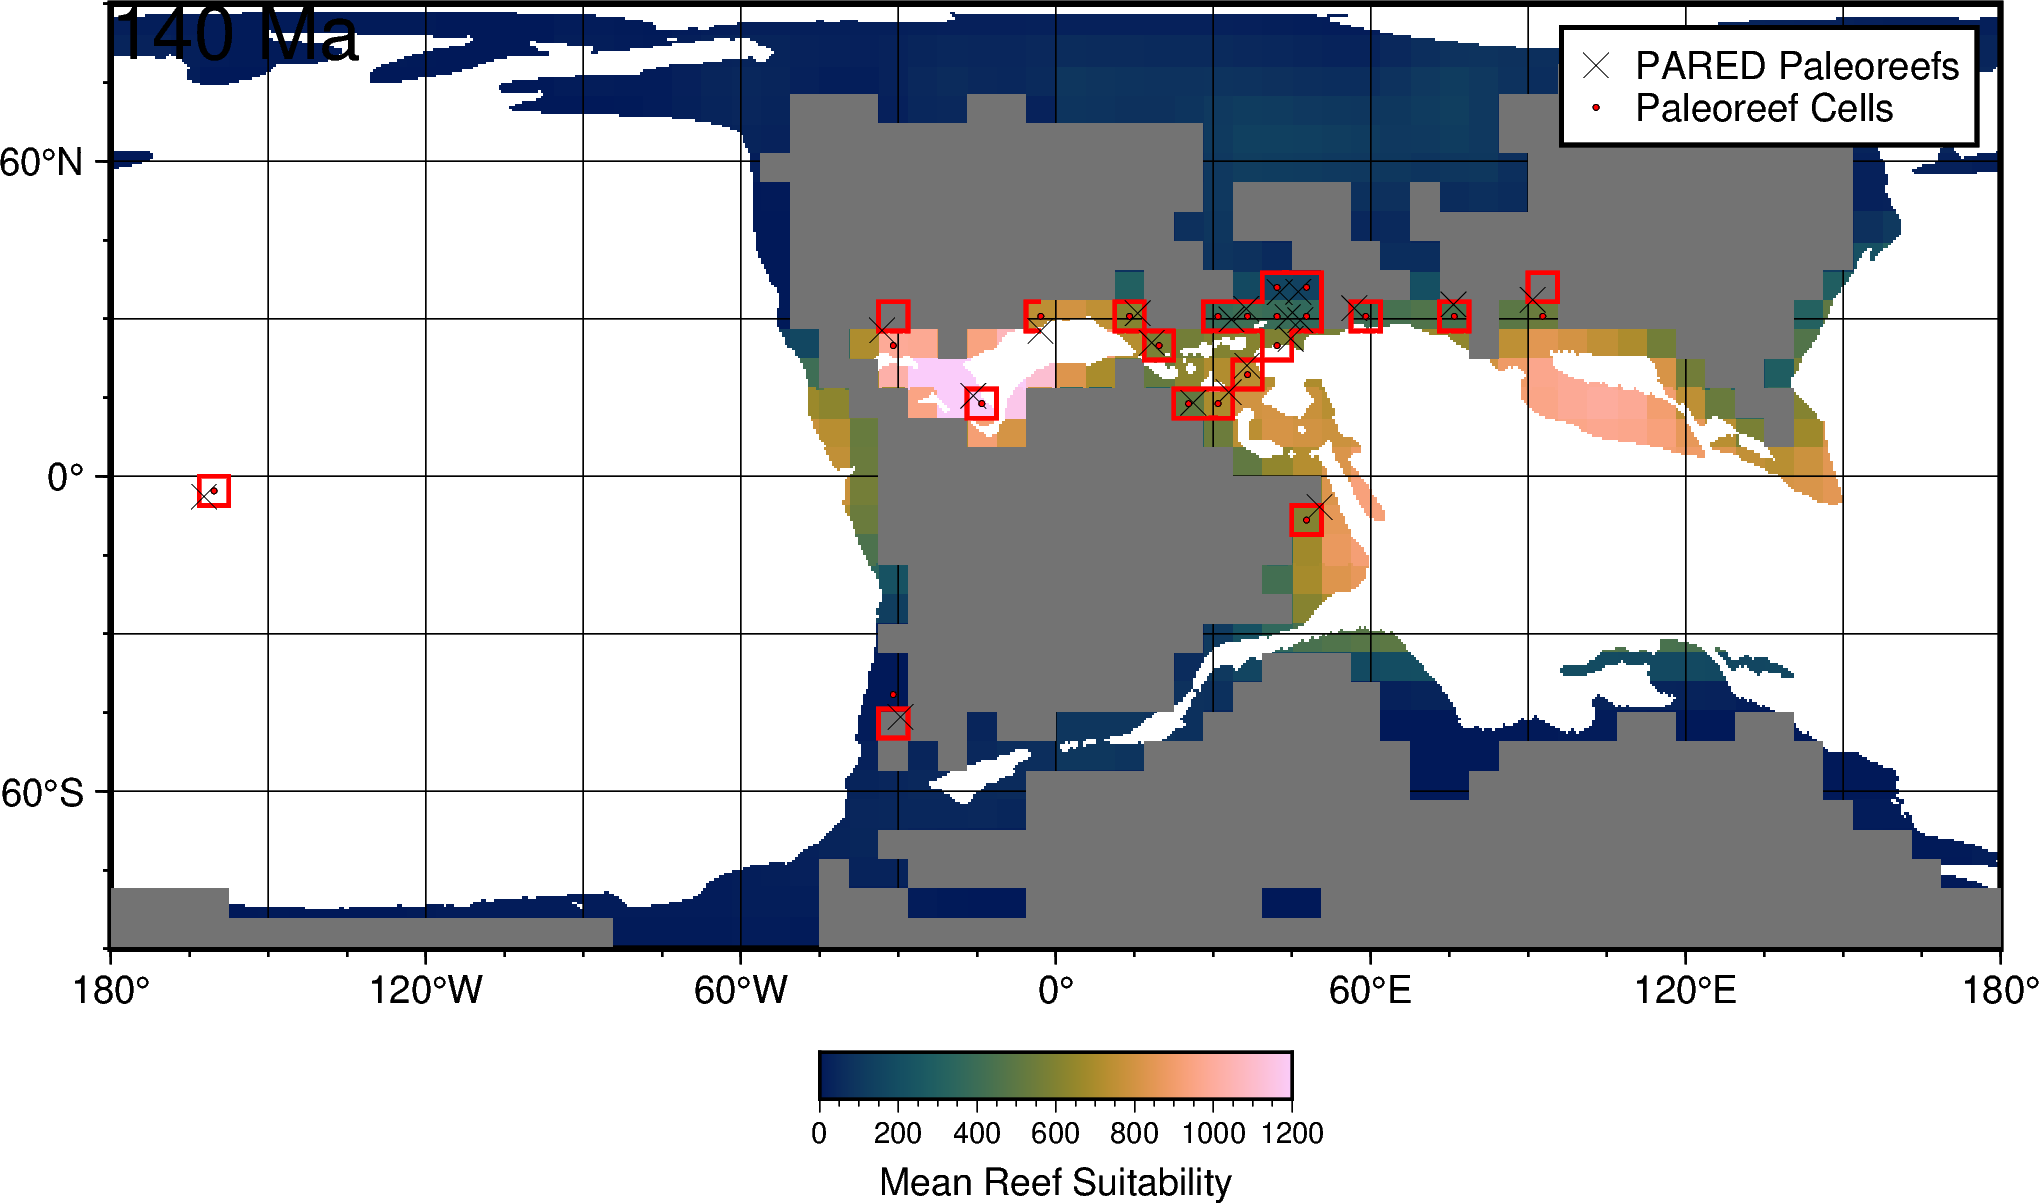

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


No valid subset found at 87.1875, 41.552284240722656
No valid subset found at 87.1875, 41.552284240722656


grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples of the grid increment (0.499305)
grdimage [WARNING]: Current region (-R) setting in longitude is -180 to 180
grdimage [WARNING]: Adjusted region (-R) setting in longitude is -180 to 180
grdimage [INFORMATION]: Spherical approximation used
g

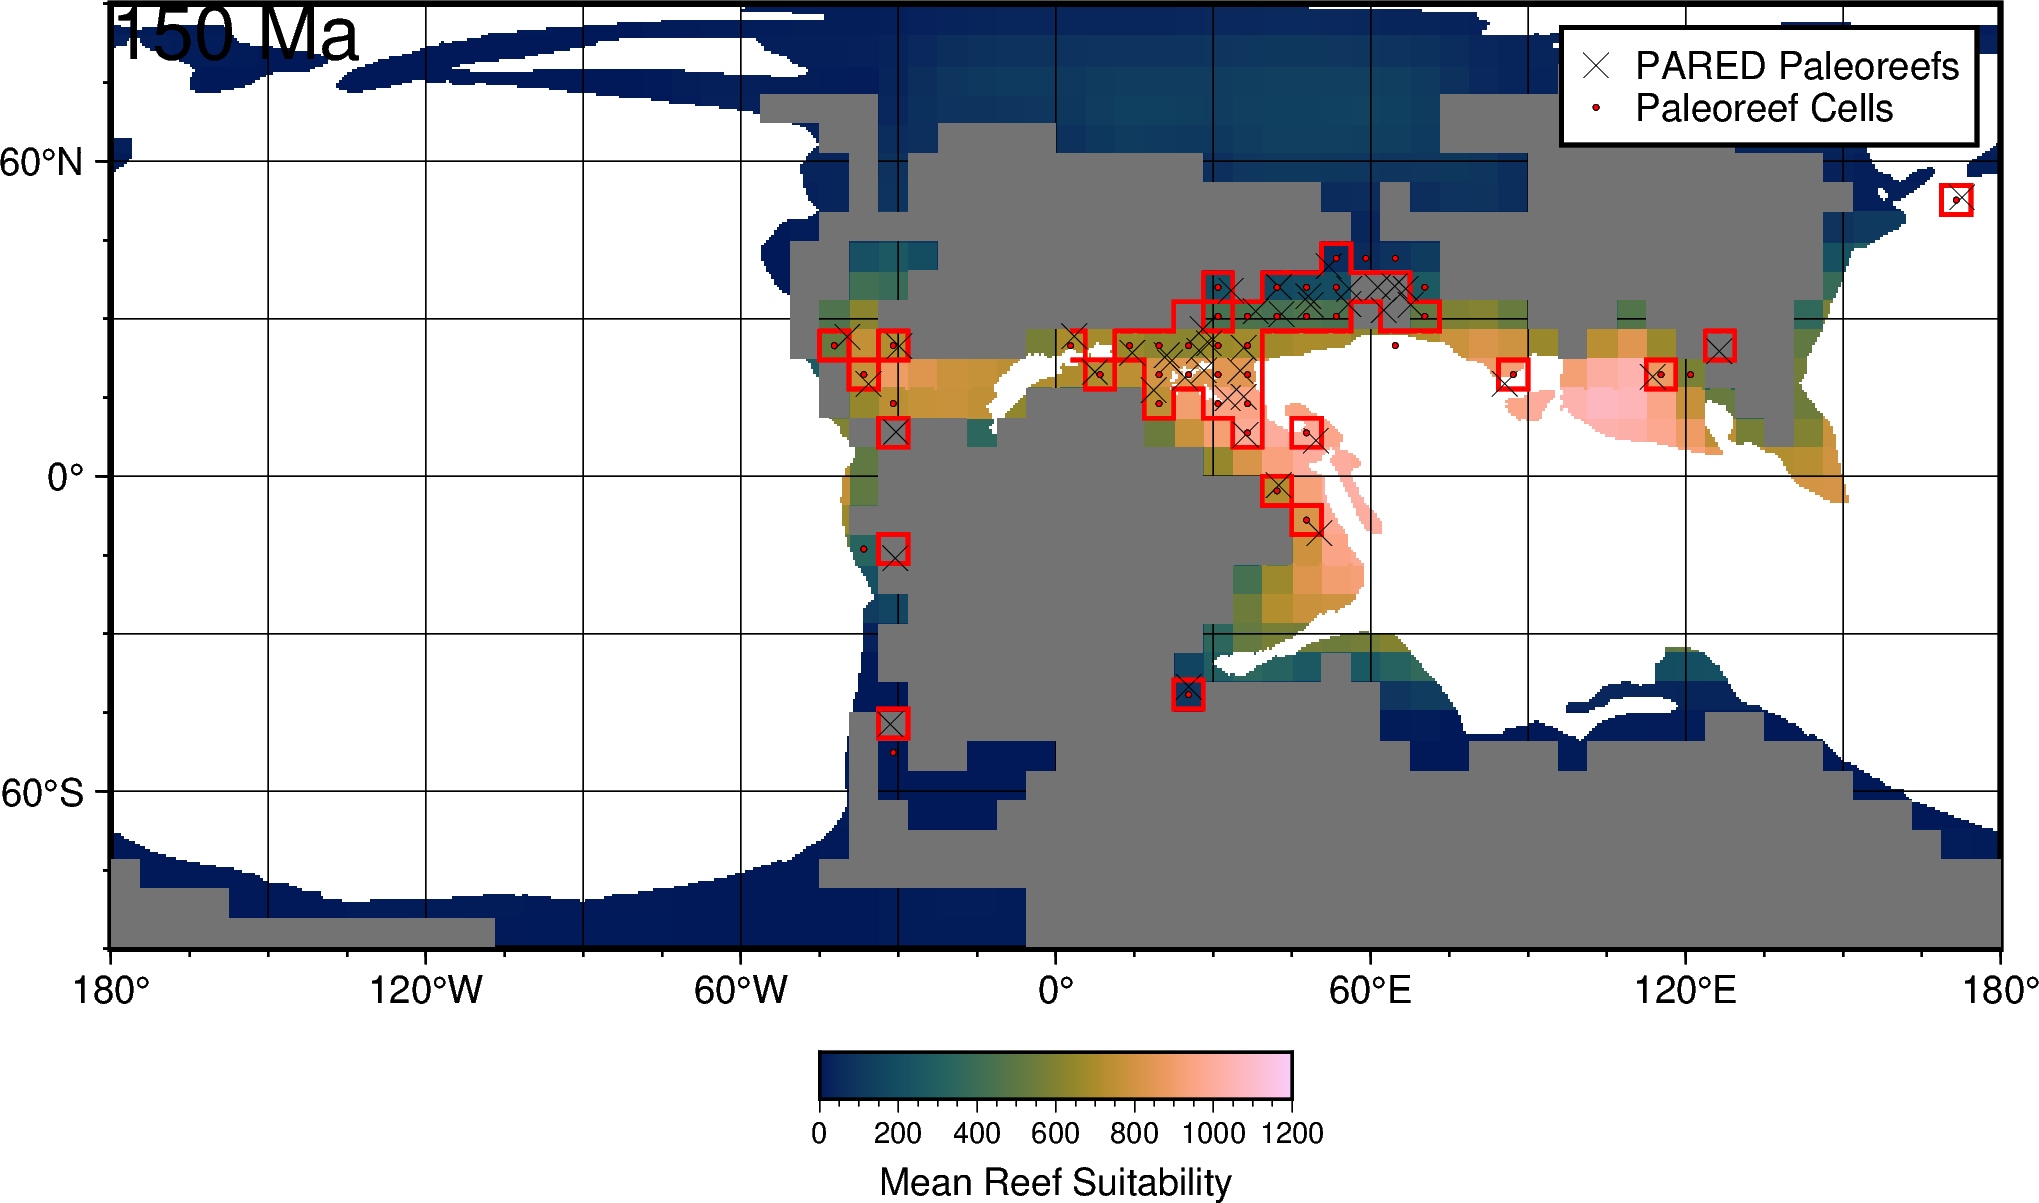

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

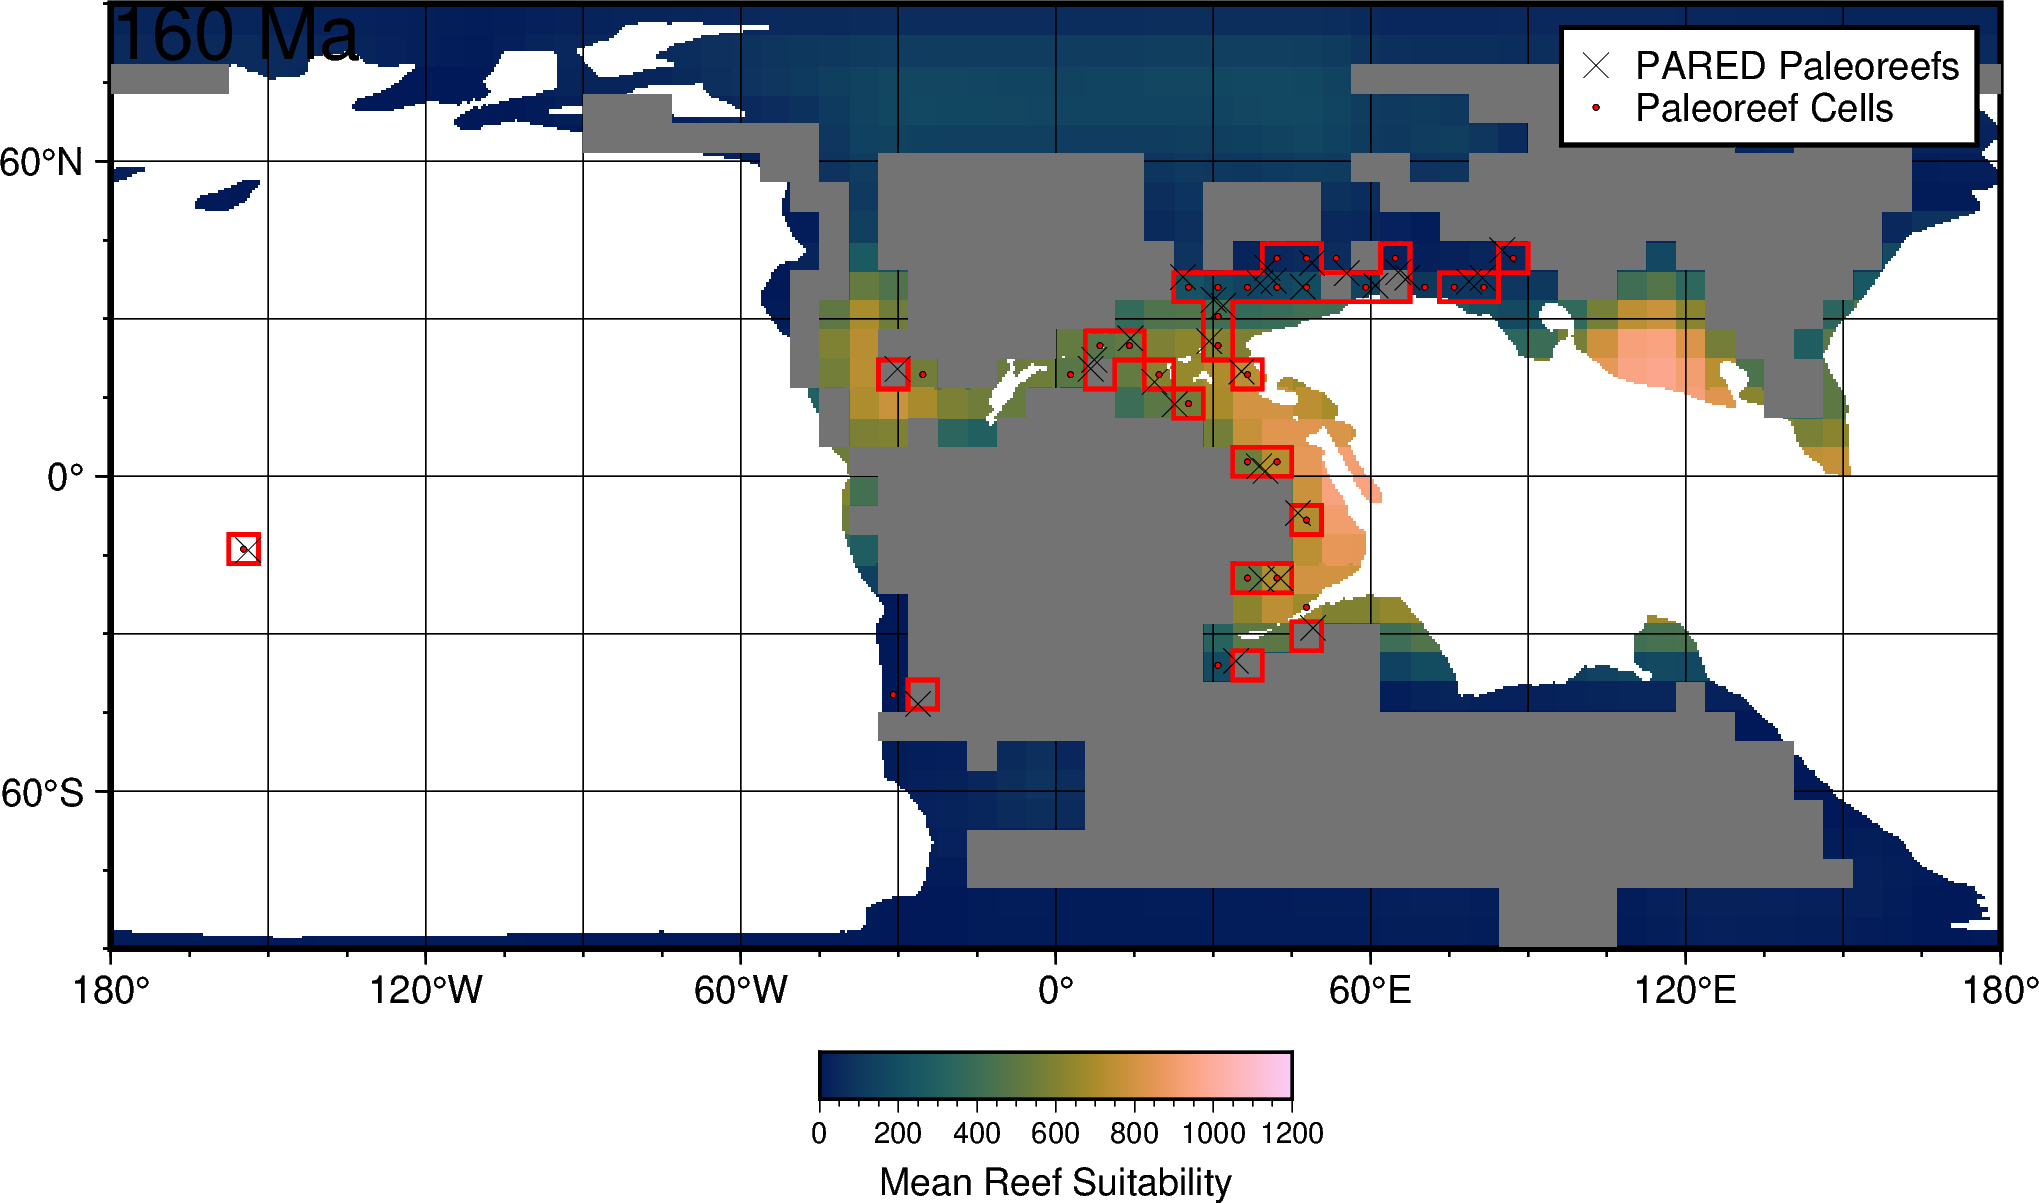

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


No valid subset found at 132.1875, 36.011329650878906
No valid subset found at 30.9375, -36.011329650878906
No valid subset found at 30.9375, -36.011329650878906


grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples of the grid increment (0.499305)
grdimage [WARNING]: Current region (-R) setting in longitude is -180 to 180
grdimage [WARNING]: Adjusted region (-R) setting in longitude is -180 to 180
grdimage [INFORMATION]: Spherical approximation used
g

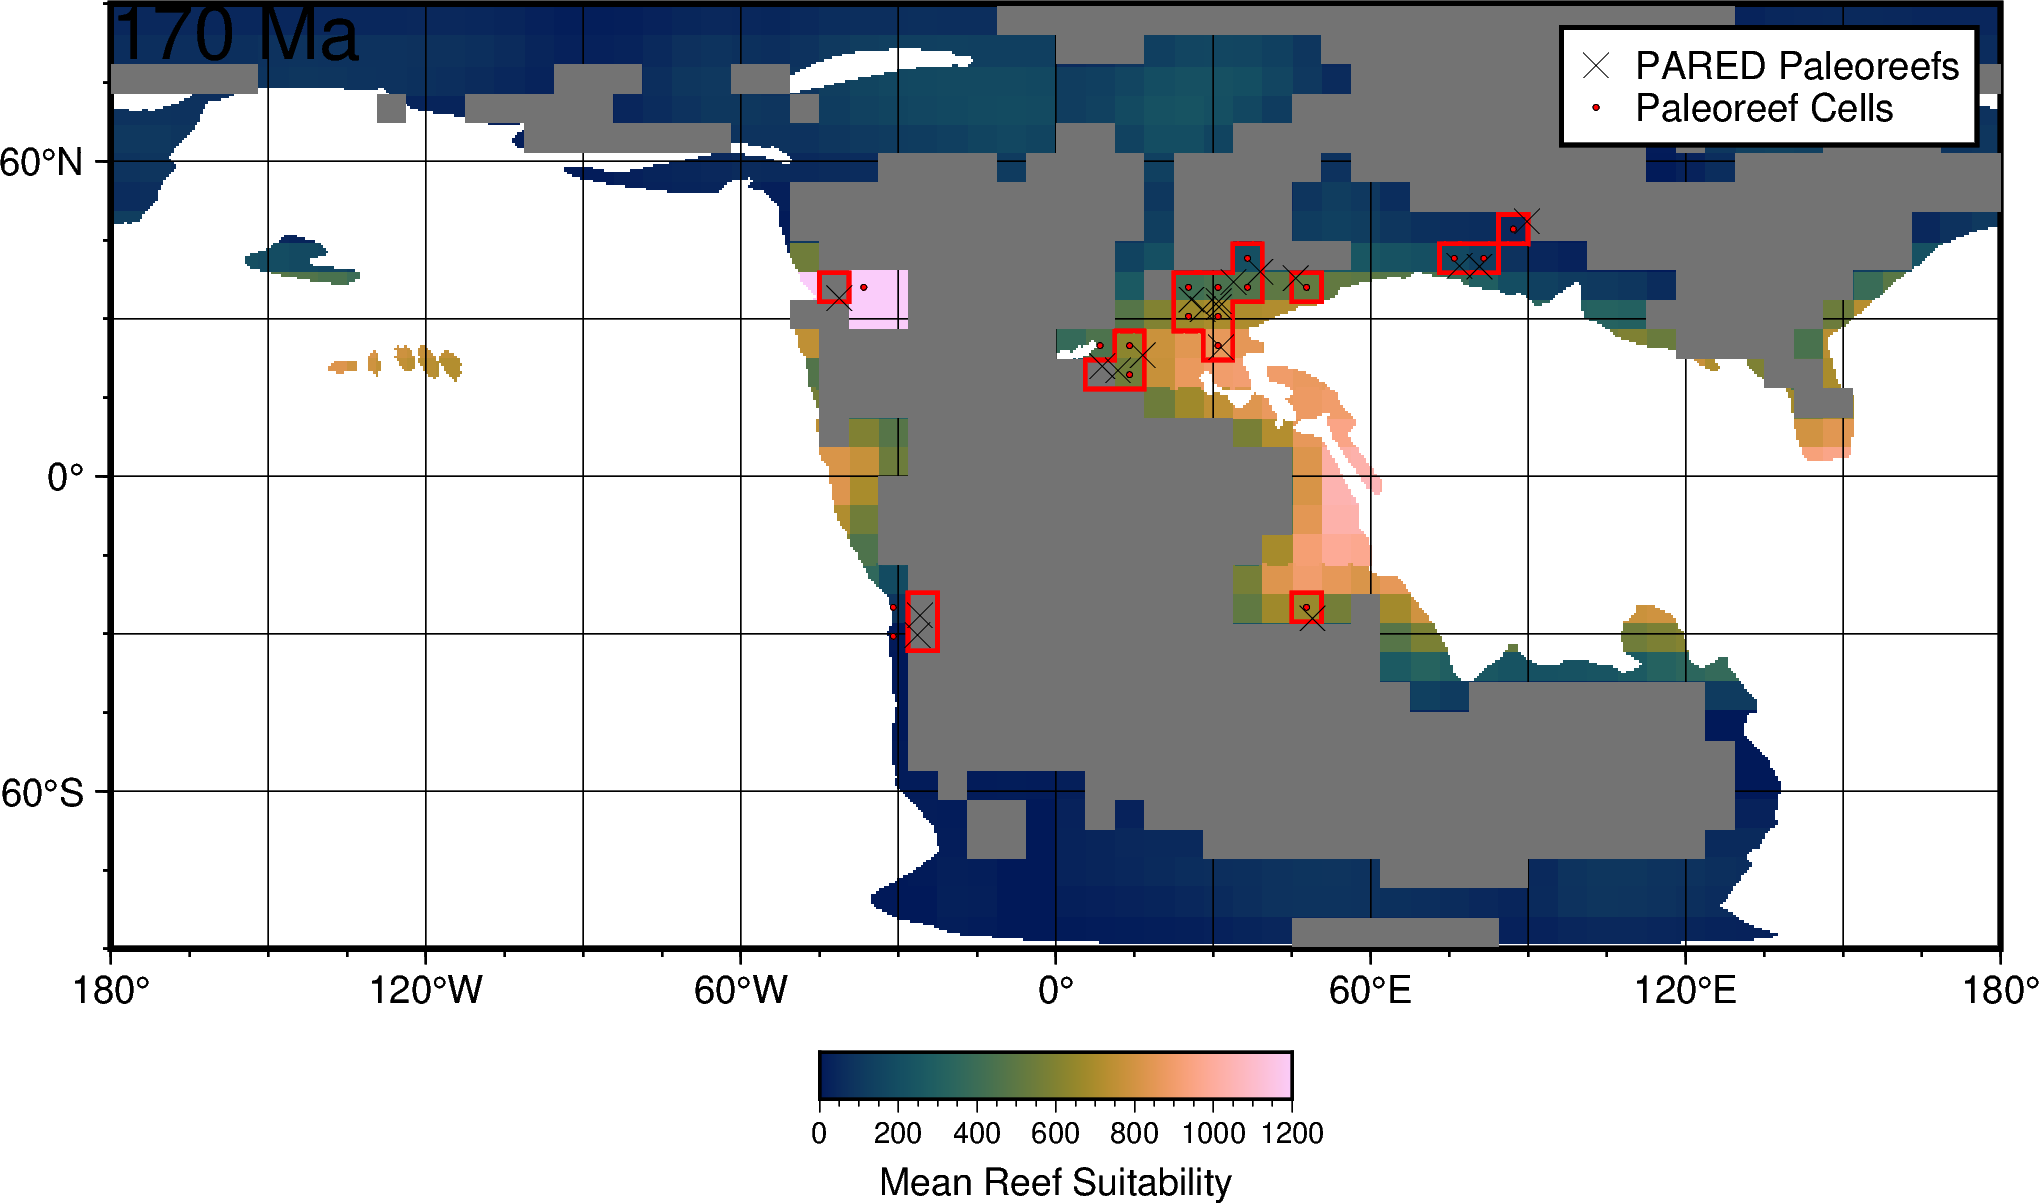

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

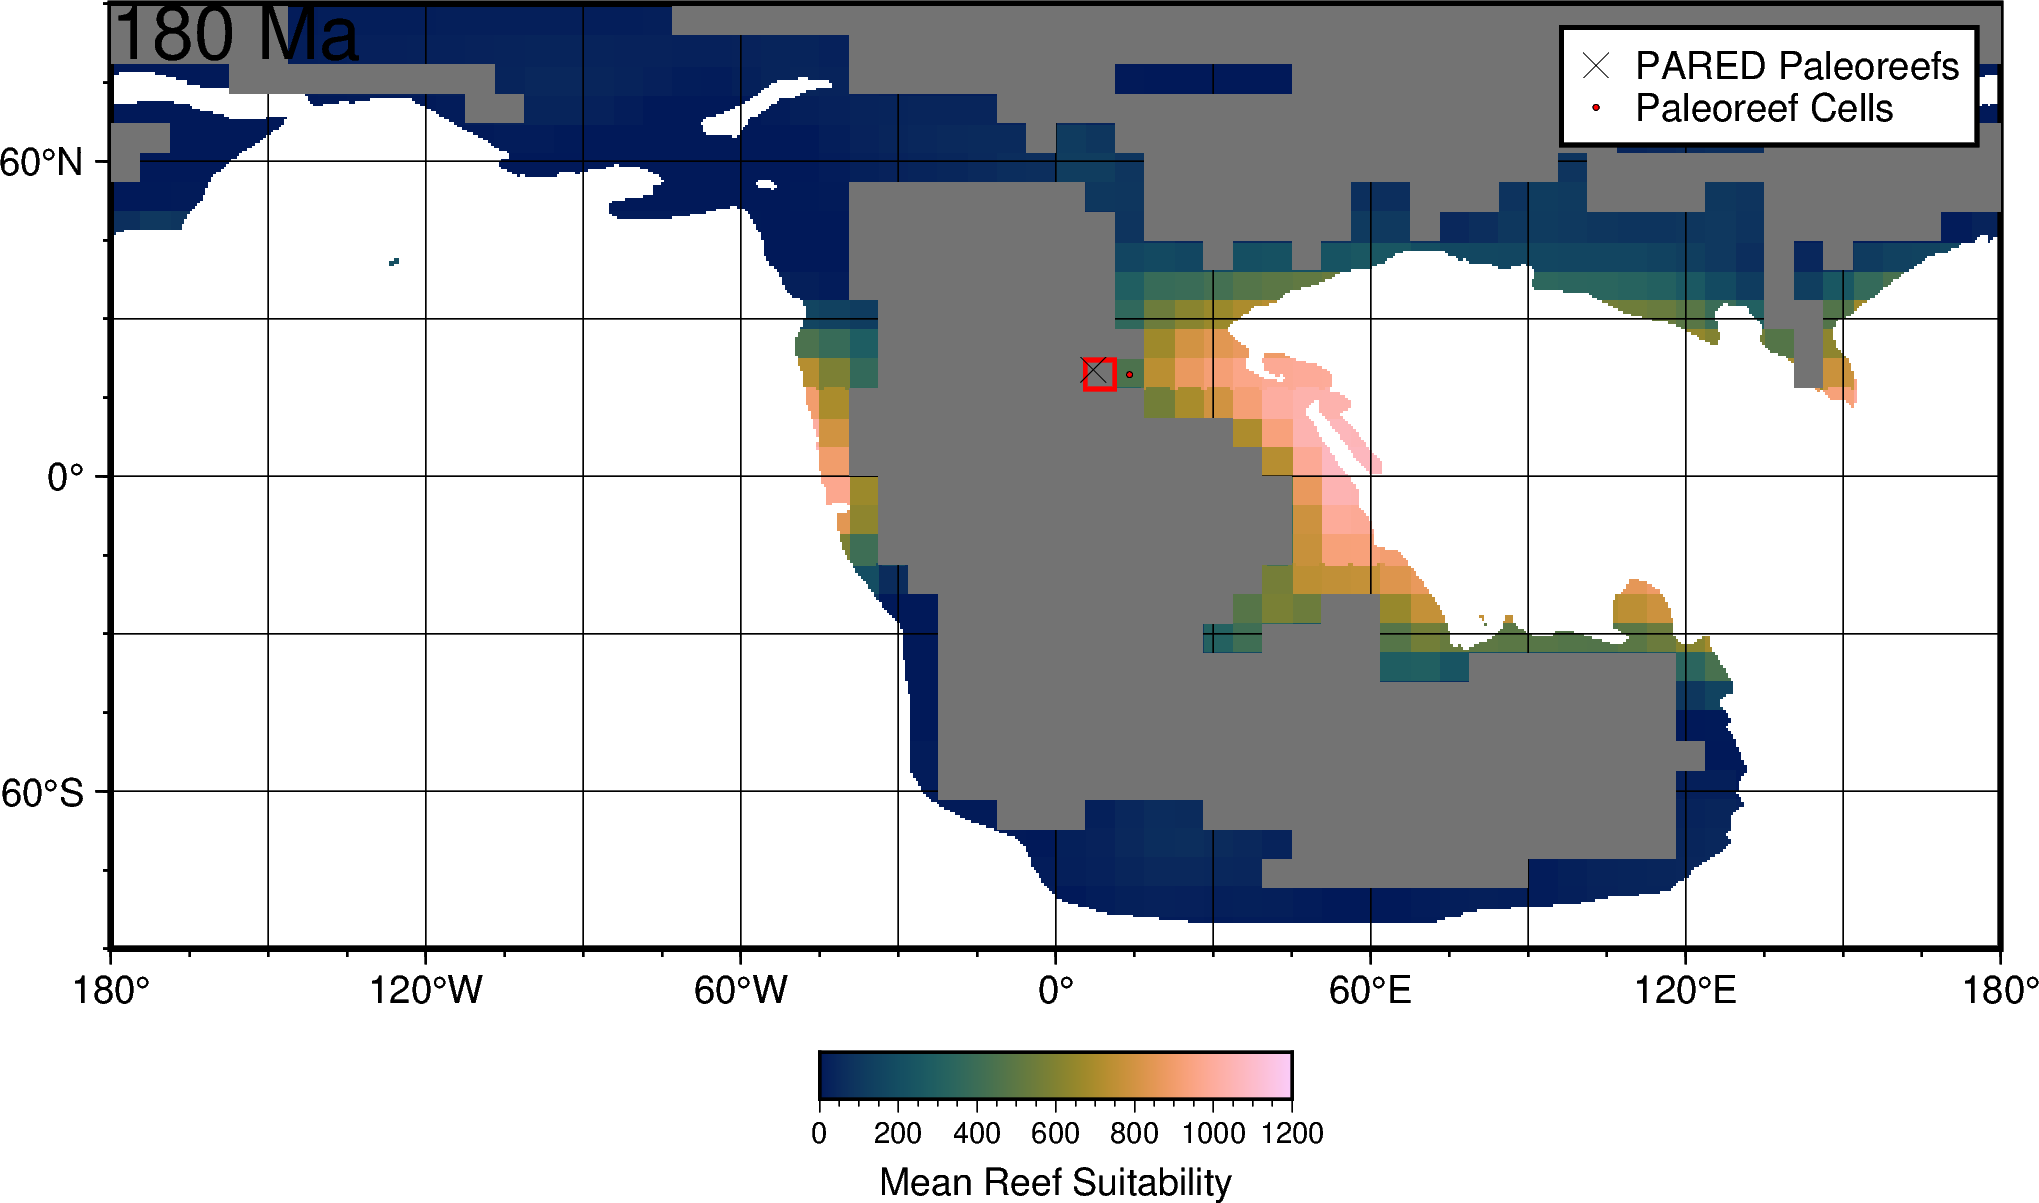

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

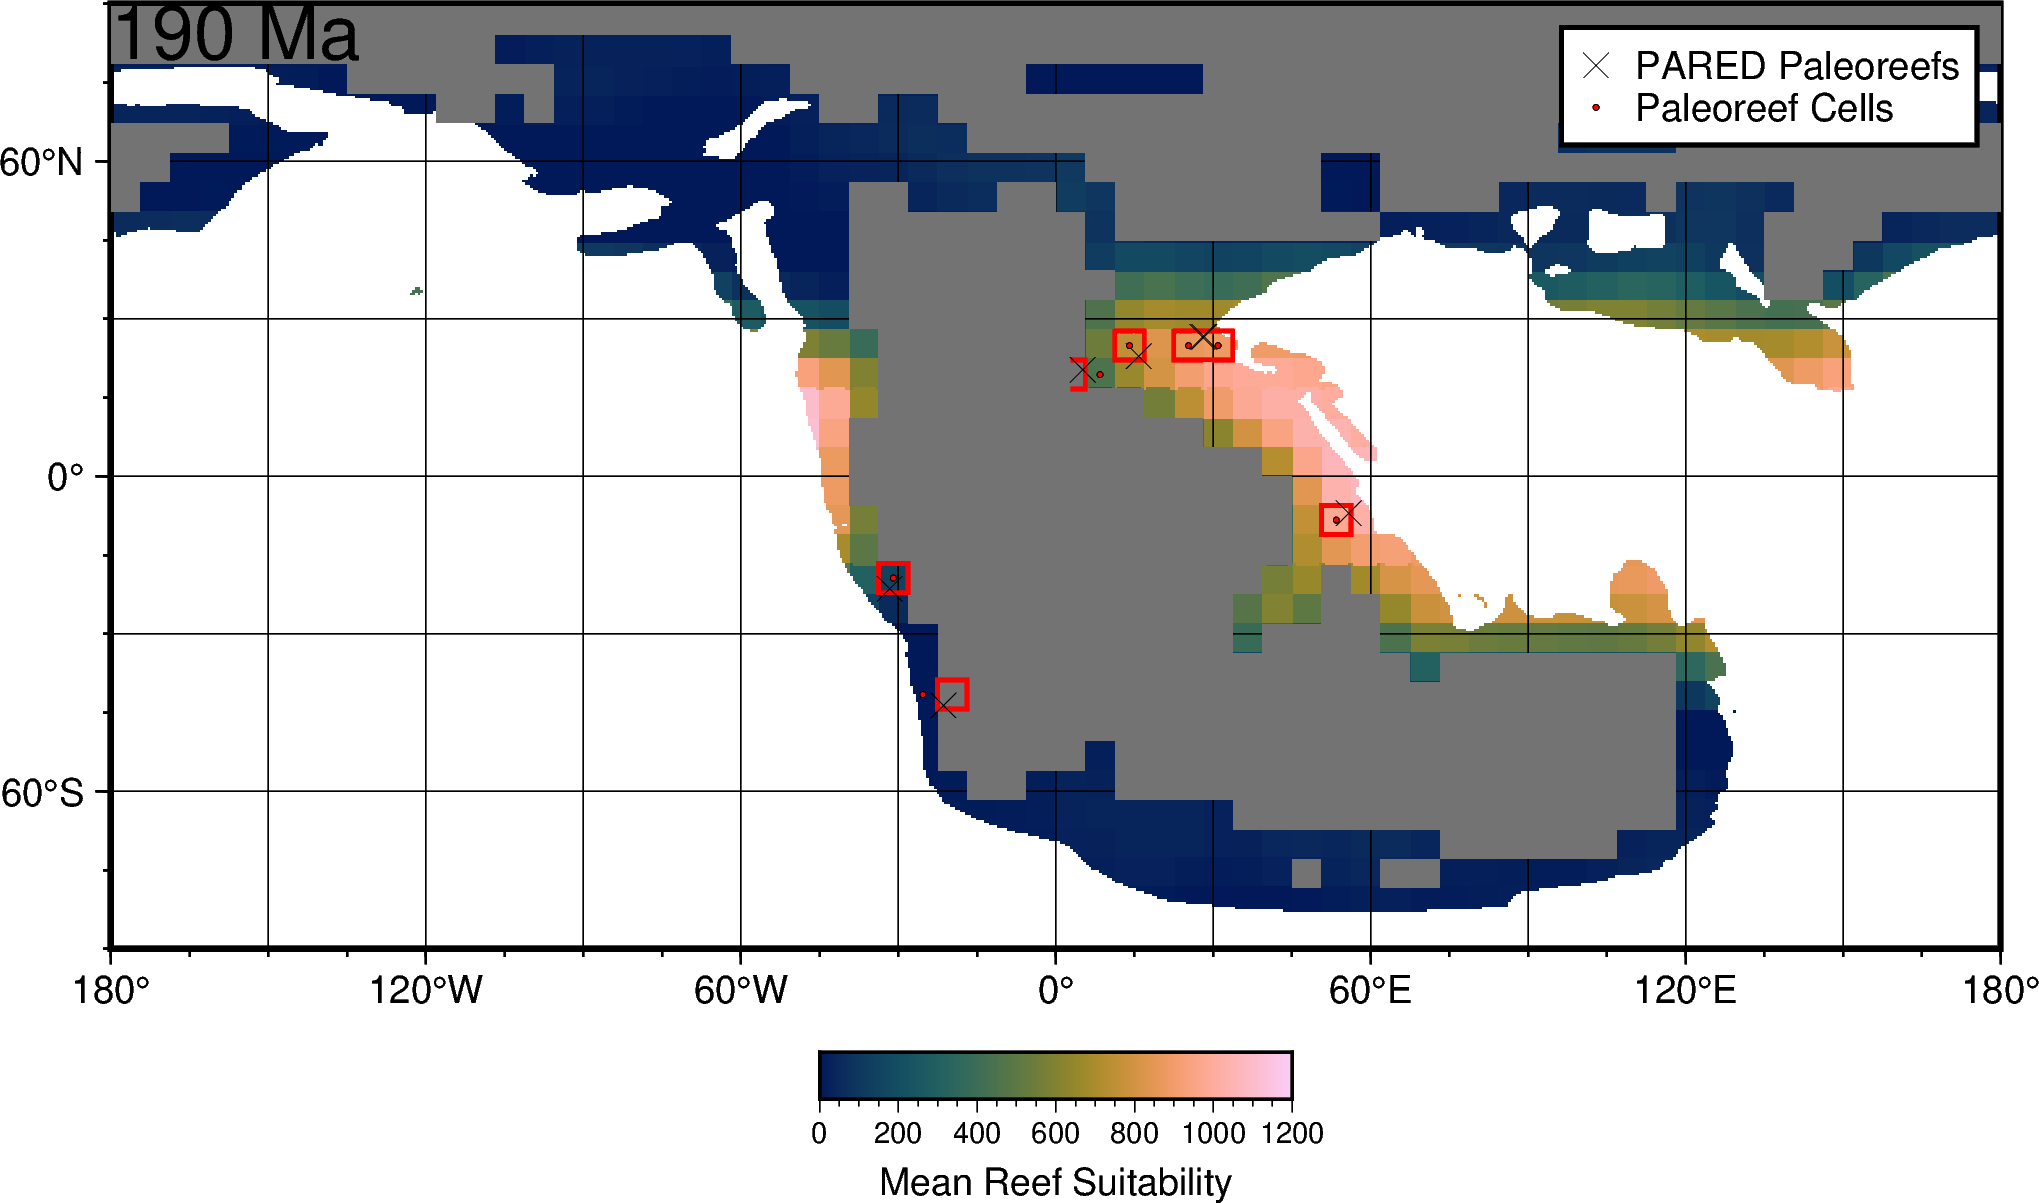

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

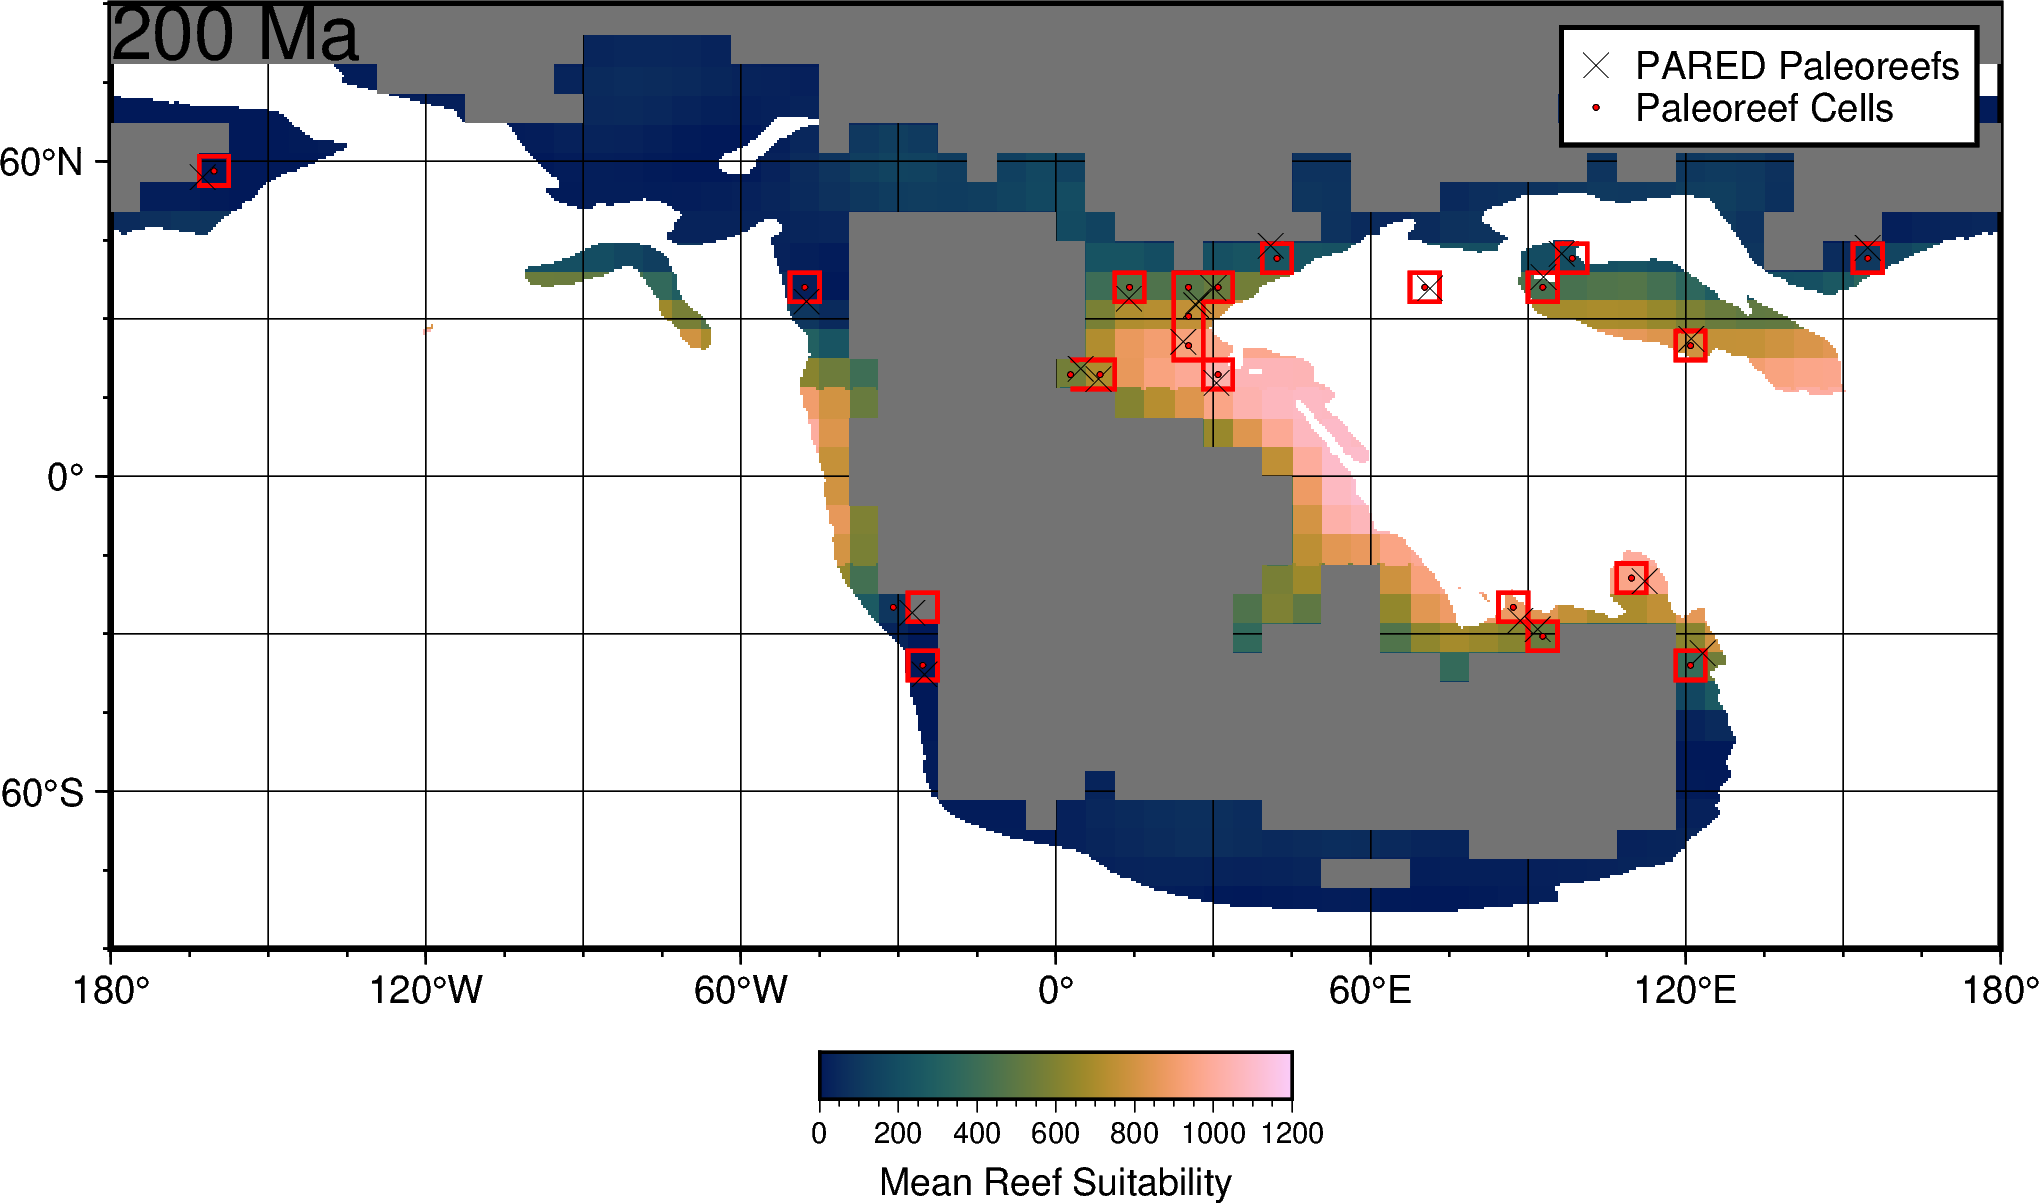

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no defau

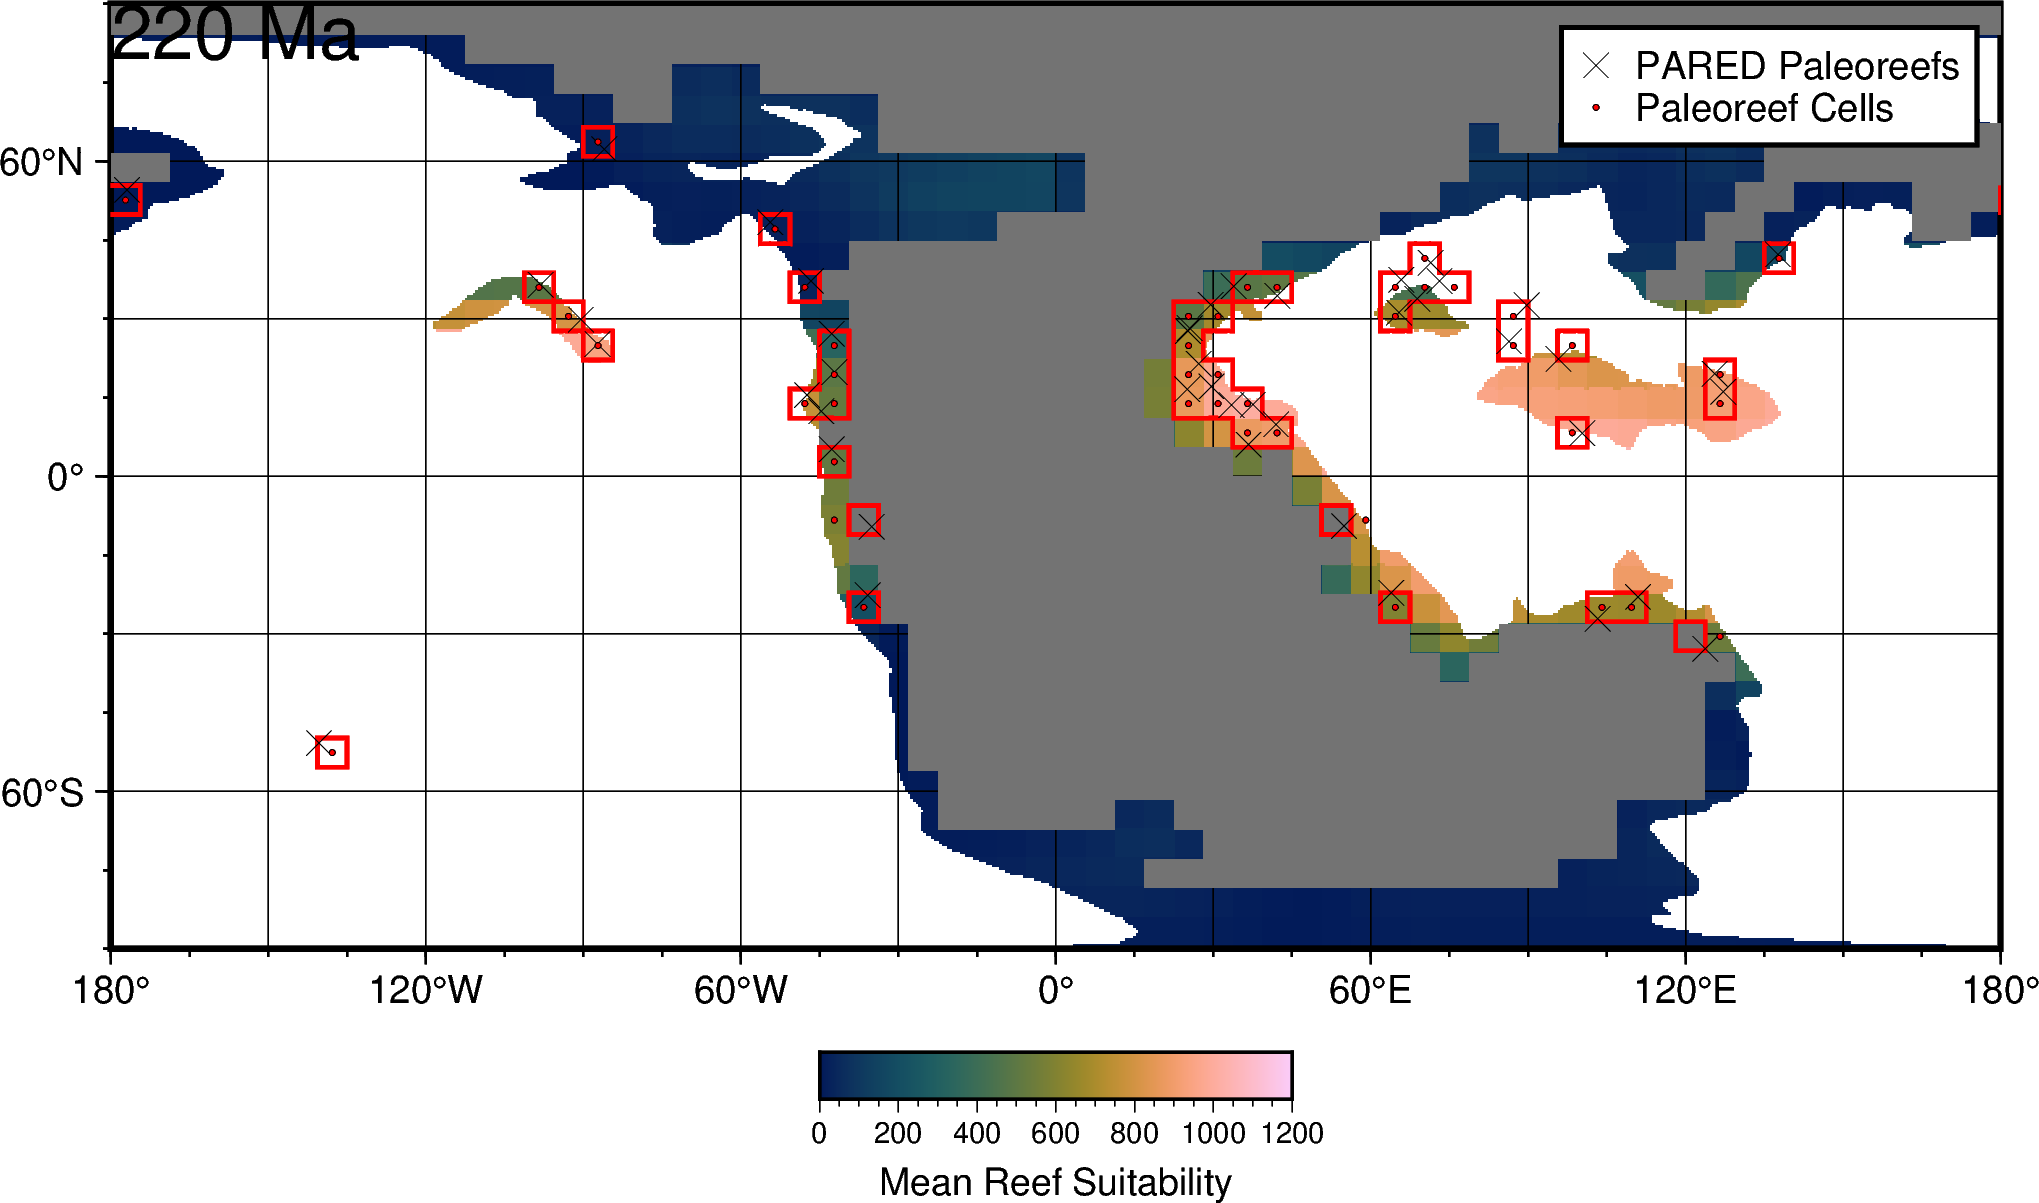

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

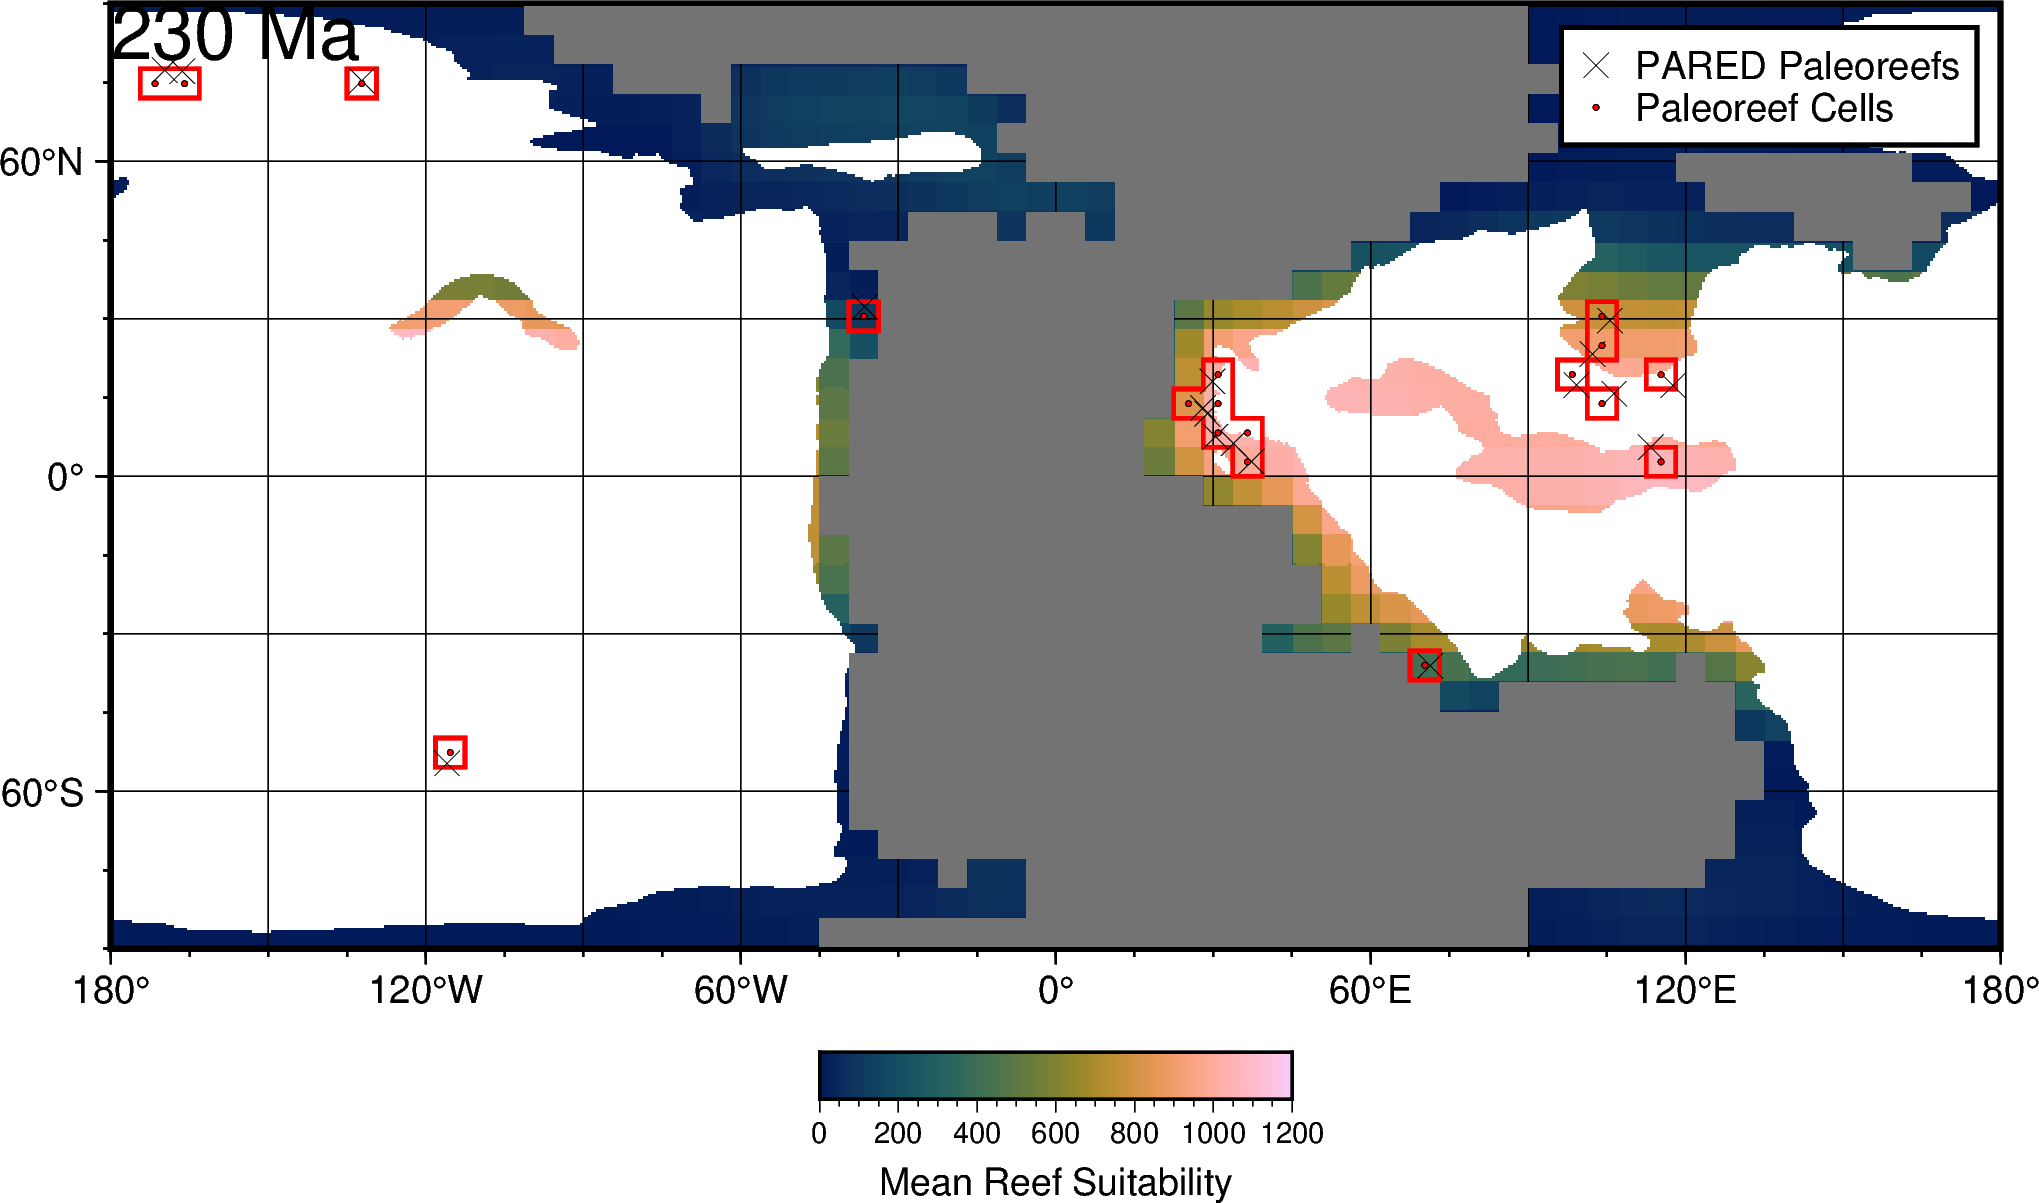

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

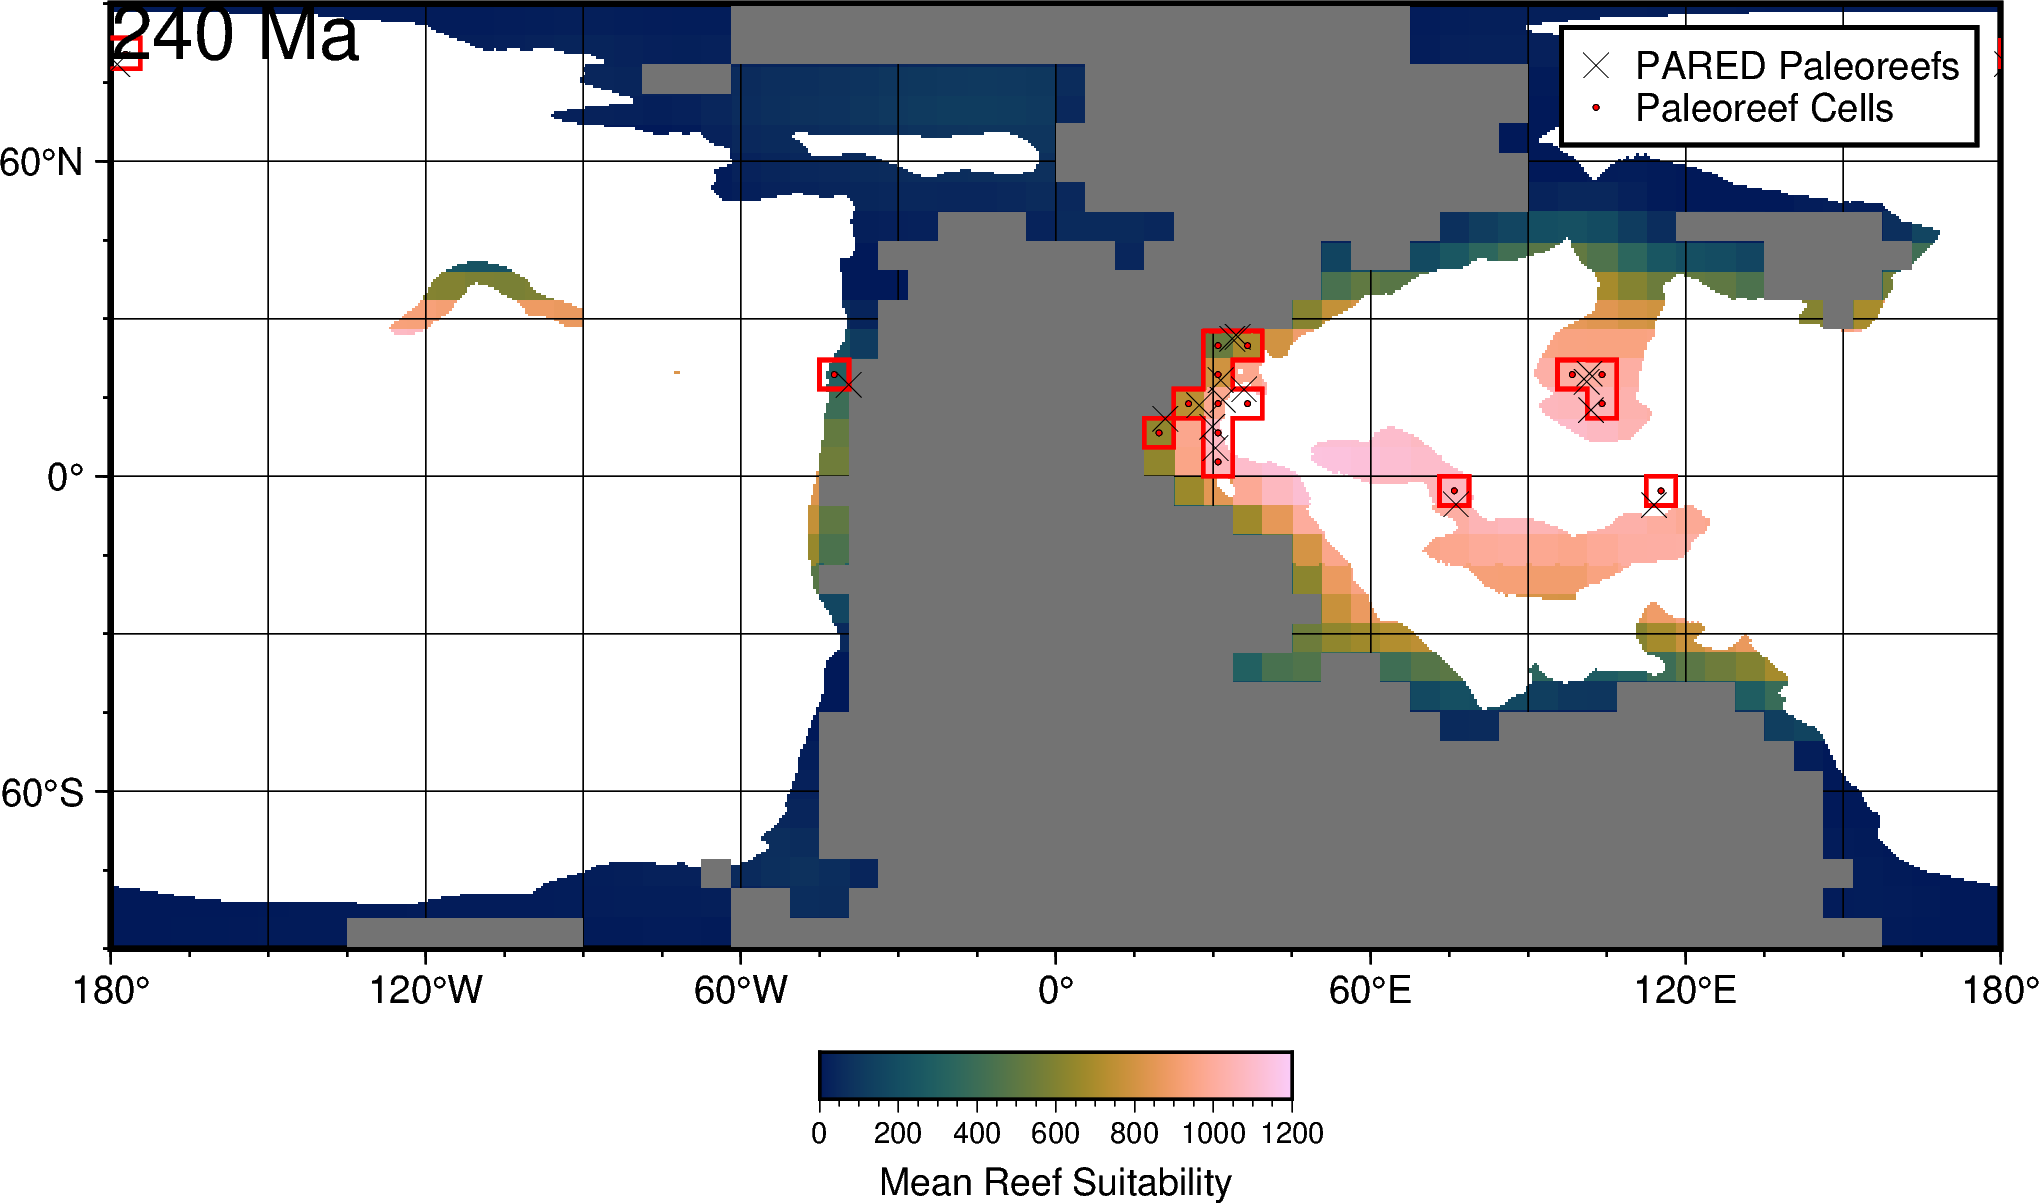

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Auto-frame interval for x-axis (item 0): a60f15
grdimage [INFORMATION]: Auto-frame interval for y-axis (item 0): a60f15
grdimage [INFORMATION]: Map scale is 2501.89 km per cm or 1:2.50189e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp2.nc
grdimage [INFORMATION]: netCDF grid tmp2.nc has no default CPT.
grdimage [WARNING]: Your grid is pixel-registered, the projection is simply longlat, and plot region is a full 360 degrees in longitude.
grdimage [WARNING]: Due to lack of repeated boundary nodes, -Rw/e must be given in multiples o

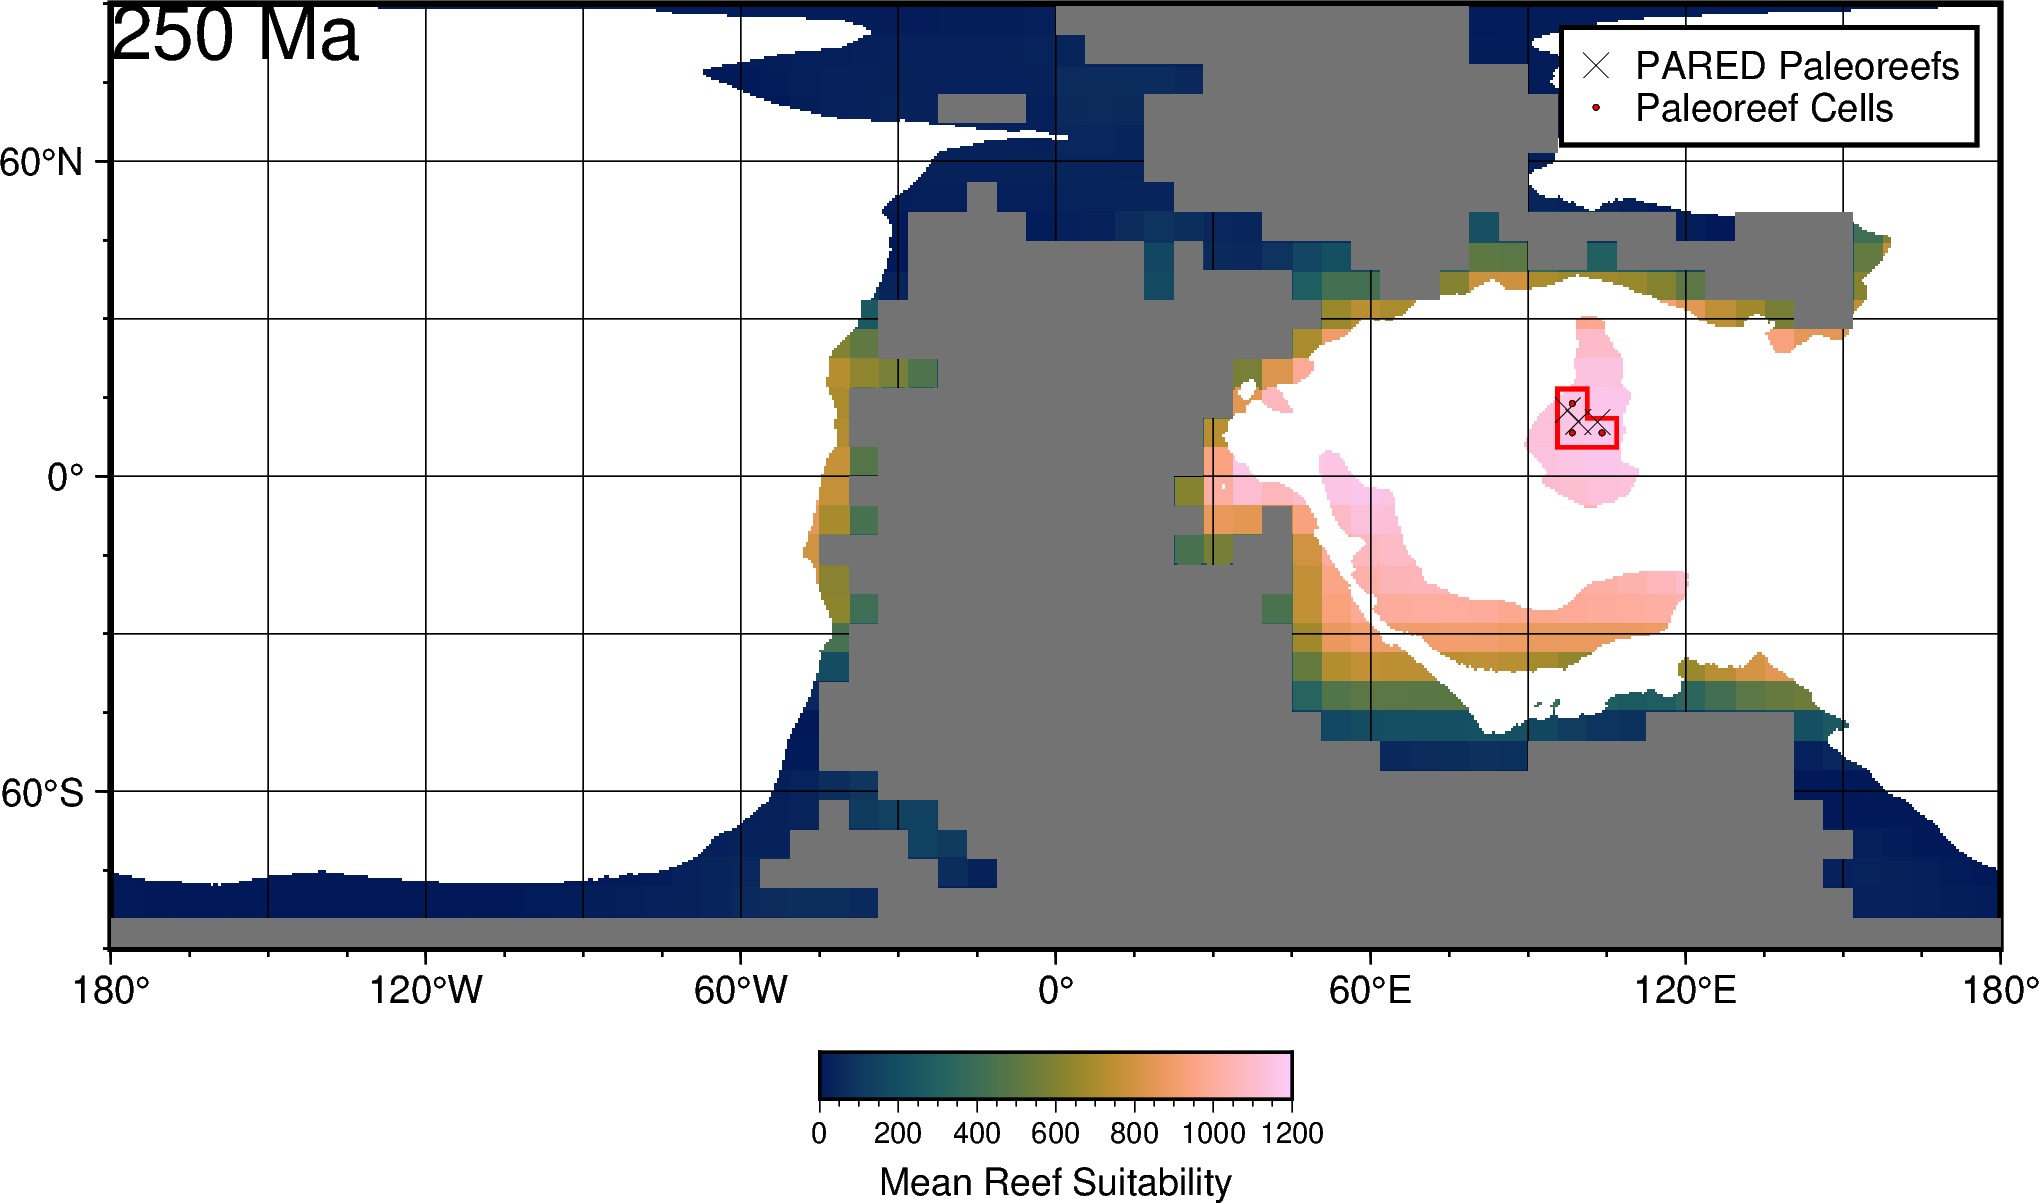

In [51]:
proj="Q16" # Cylindrical equidistant projection
# proj="H16"
region='d' # d = Global region

pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1200], background=True, output='reefProb.cpt')
pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)

figFolder = f'meanEnsemble_{model}'
if os.path.exists(figFolder):
    shutil.rmtree(figFolder)
os.makedirs(figFolder)
for age in np.arange(0,260,10):
# for age in [10]:
    ensemblePath = f'photozoan/proj_{modelName}_{age}Ma/proj_{modelName}_{age}Ma_photozoan_ensemble.tif'

    # climateData = f'../climateModelData/{modelName}_1120/{age}Ma_nc_outputs/3000-12-30_plasim.nc'
    climateData = f'../climateModelData/{modelName}_1120/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc'
    climateData = xr.open_dataset(climateData)
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)

    topo = f"{topoPath}/topo_{age}_filled.nc"
    data = clip2shelves(age, ensemblePath, topo, dontClip=False)
    
    os.makedirs(f'data_{modelName}', exist_ok=True)
    if os.path.exists(f'data_{modelName}/{age}.nc'):
        os.remove(f'data_{modelName}/{age}.nc')
    data.to_netcdf(f'data_{modelName}/{age}.nc')

    topoDS = xr.open_dataset(topo)
    land = topoDS.where(topoDS <= 0.1, 1)
    land = land.where(land > 0.1, 0)

    # Move each point to center of the grid cell then find nearest ocean cell for those that are on land
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
    
    # Get paleoreef data and keep it in a new dataframe called select
    df = pared[(pared['mid'] > age-5) & (pared['mid'] < age+5)].copy()
    if df.empty:
        continue
    select = pd.DataFrame({
        'longitude': df[paleoLon],
        'latitude': df[paleoLat]
    })
    select['longitude'] = select['longitude'].where(select['longitude'] >= 0, select['longitude'] + 360) # convert to 0-360

    # Get cell coordinates of each reef point then move any points on land to the nearest ocean cell
    reefLandsea = []
    nearestValid = []
    for index, row in select.iterrows():
        # This will get the coords of the cell nearest to the reef point and whether the cell is land or ocean
        landseaVal = climateData['landNAN'].sel(longitude=row['longitude'], latitude=row['latitude'], method='nearest')
        reefLandsea.append((landseaVal.values.item(), landseaVal.longitude.values.item(), landseaVal.latitude.values.item()))

        if np.isnan(landseaVal.values.item()):
            # Find the nearest ocean cell - this also needs the non-interpolated reef coords as a 'tie breaker' when the nan cell is between two ocean cells
            nearest = find_nearest_valid(climateData, landseaVal.longitude.values.item(), landseaVal.latitude.values.item(), row['longitude'], row['latitude'], 'landNAN', radius=6)
        else:
            nearest = (np.nan, np.nan, np.nan) # return nans if not within the defined radius
        nearestValid.append(nearest)
    
    # Now put the nearest coords and land/ocean values into the select dataframe
    select['reefLandsea'] = [landseaVal[0] if landseaVal is not None else np.nan for landseaVal in reefLandsea]
    select['realignedLon'] = [landseaVal[1] if landseaVal is not None else np.nan for landseaVal in reefLandsea]
    select['realignedLat'] = [landseaVal[2] if landseaVal is not None else np.nan for landseaVal in reefLandsea]
    select['nearestLandsea'] = [item[0] if item is not None else np.nan for item in nearestValid]
    select['nearestLon'] = [item[1] if item is not None else np.nan for item in nearestValid]
    select['nearestLat'] = [item[2] if item is not None else np.nan for item in nearestValid]

    # Have a final set of columns that is either the cell coord that the reef point is in or the one that is nearest to it
    select = select[(select['nearestLandsea'] == 0) | (select['reefLandsea'] == 0)]
    select['finalLon'] = np.where(select['nearestLandsea'] == 0, select['nearestLon'], select['realignedLon'])
    select['finalLat'] = np.where(select['nearestLandsea'] == 0, select['nearestLat'], select['realignedLat'])

    # Remove the FillValue that xarray automaticcaly puts in (stuffs up some of the plotting)
    enc = dict(_FillValue=None)
    encoding = {var:enc for var in climateData.coords}
    if os.path.exists('climateData.nc'):
        os.remove('climateData.nc')
    climateData.to_netcdf('climateData.nc',encoding=encoding)
    
    # select = pd.DataFrame(filtered_points, columns=['longitude', 'latitude'])
    select = select.drop_duplicates(subset=['finalLon', 'finalLat'], keep='first')
    os.makedirs(f'selectedPoints_{modelName}', exist_ok=True)
    if os.path.exists(f'selectedPoints_{modelName}/{age}.csv'):
        os.remove(f'selectedPoints_{modelName}/{age}.csv')
    select.to_csv(f'selectedPoints_{modelName}/{age}.csv',index=False)
    
    fig = pygmt.Figure()
    pygmt.config(MAP_FRAME_TYPE="plain")
    
    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To remove negative values
    data['e_mean_shelf'].to_netcdf('tmp.nc')
    ! gmt grdedit tmp.nc -L+n -Gtmp2.nc
    
    fig.grdimage('tmp2.nc',projection=proj, region=region, cmap='reefProb.cpt',nan_transparent=False, interpolation='b', frame='afg30',verbose=True)
    fig.grdimage('climateData.nc?landsea', projection=proj, region=region, cmap='landGray.cpt', nan_transparent='+z0')

    # Get contours to draw around cells
    contours = get_contours(climateData, select['realignedLon'], select['realignedLat'], 'landsea')

    # Plot each contour 
    for contour in contours:
        # Interpolate the contour/pixel coordinates into lats/lons
        ys, xs = contour[:, 0], contour[:, 1]
        lon = climateData['longitude'].values
        lat = climateData['latitude'].values
        contour_lon = np.interp(xs, np.arange(len(lon)), lon)
        contour_lat = np.interp(ys, np.arange(len(lat)), lat)
        
        # Plot the outline
        fig.plot(x=contour_lon, y=contour_lat, pen="1p,red", projection=proj, region=region)

    # Plot the original paleoreef locations followed by the point we use in the middle of the cell (and possibly the nearest ocean cell)
    fig.plot(x=select['longitude'], y=select['latitude'], style="x0.3c", pen="0.07p,black", fill="black", label='PARED Paleoreefs', region=region)
    fig.plot(x=select['finalLon'], y=select['finalLat'], style="c0.05c", pen="0.01p,black", fill="red", label='Paleoreef Cells', region=region)

    # everything needs to be re-scaled when changing the color bar width for some dumb gmt reason
    def re_scale(width):
        return np.sqrt(width/15) 
    MAP_TICK_LENGTH_PRIMARY=3
    MAP_TICK_LENGTH_SECONDARY=1.5
    MAP_ANNOT_OFFSET=-2.5
    cbar_len = 4
    scaling = re_scale(cbar_len)
    with pygmt.config(
        FONT_ANNOT=f"{7/scaling}p",
        FONT_LABEL=f"{9/scaling}p",
        MAP_TICK_LENGTH_PRIMARY=f"{MAP_TICK_LENGTH_PRIMARY/scaling}p",
        MAP_TICK_LENGTH_SECONDARY=f"{MAP_TICK_LENGTH_SECONDARY/scaling}p",
        MAP_ANNOT_OFFSET=f"{MAP_ANNOT_OFFSET/scaling}p",
    ): 
        fig.colorbar(cmap='reefProb.cpt', position=f"JBC+w{cbar_len}c/0.4c+h", frame=["a200f50", "x+lMean Reef Suitability"])

    fig.legend()
    fig.text(position='TL', font='18p', text=f'{age} Ma', verbose=True, no_clip=True)
    fig.savefig(f'{figFolder}/{age}_{co2}ppm_meanEnsemble.png',transparent=True)
    fig.show()


In [52]:
animation(figFolder)

0_4480ppm_meanEnsemble.png
10_4480ppm_meanEnsemble.png
20_4480ppm_meanEnsemble.png
30_4480ppm_meanEnsemble.png
40_4480ppm_meanEnsemble.png
50_4480ppm_meanEnsemble.png
60_4480ppm_meanEnsemble.png
70_4480ppm_meanEnsemble.png
80_4480ppm_meanEnsemble.png
90_4480ppm_meanEnsemble.png
100_4480ppm_meanEnsemble.png
110_4480ppm_meanEnsemble.png
120_4480ppm_meanEnsemble.png
130_4480ppm_meanEnsemble.png
140_4480ppm_meanEnsemble.png
150_4480ppm_meanEnsemble.png
160_4480ppm_meanEnsemble.png
170_4480ppm_meanEnsemble.png
180_4480ppm_meanEnsemble.png
190_4480ppm_meanEnsemble.png
200_4480ppm_meanEnsemble.png
220_4480ppm_meanEnsemble.png
230_4480ppm_meanEnsemble.png
240_4480ppm_meanEnsemble.png
250_4480ppm_meanEnsemble.png


## Plot Probability

In [53]:
scotese_data = 'data_2024-10-08_realigned_scotese_paleo_shallowSea'
pmag_data = 'data_2024-07-23_realigned_earthbyte_paleo_PaleomagRef'

probs = {}
sems = {}
num = {}
percent_above_threshold = {}
threshold = 400
for age in np.arange(0,260,10):
    scoteseDS = xr.open_dataset(f'{scotese_data}/{age}.nc')
    pmagDS = xr.open_dataset(f'{pmag_data}/{age}.nc')

    try:
        selectPmag = pd.read_csv(f'selectedPoints_2024-07-23_realigned_earthbyte_paleo_PaleomagRef/{age}.csv')
        selectScotese = pd.read_csv(f'selectedPoints_2024-10-08_realigned_scotese_paleo_shallowSea/{age}.csv')
    except Exception as e:
        print(e)
        num[age] = (0, 0)
        continue

    
    Sprobs = []
    Pprobs = []
    for i in range(len(selectPmag)):
        Plat = selectPmag['finalLat'][i]
        Plon = selectPmag['finalLon'][i]

        pmagDS['wmean'] = xr.where(pmagDS['wmean']>1200,1200,pmagDS['wmean'])
        Pprob = pmagDS['wmean'].sel(lon=Plon, lat=Plat, method='nearest').values.item()
        Pprobs.append(Pprob)
    for i in range(len(selectScotese)):
        Slat = selectScotese['finalLat'][i]
        Slon = selectScotese['finalLon'][i]  
        scoteseDS['wmean'] = xr.where(scoteseDS['wmean']>1200,1200,scoteseDS['wmean'])   
        Sprob = scoteseDS['wmean'].sel(lon=Slon, lat=Slat, method='nearest').values.item()  
        Sprobs.append(Sprob)

    probs[age] = (np.mean(Sprobs), np.mean(Pprobs))
    sems[age] = (sem(Sprobs), sem(Pprobs))
    num[age] = (len(Sprobs), len(Pprobs))
    percent_above_threshold[age] = (np.sum(np.array(Sprobs) > threshold)/len(Sprobs), np.sum(np.array(Pprobs) > threshold)/len(Pprobs))


/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_5305/3995398756.py:39: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sems[age] = (sem(Sprobs), sem(Pprobs))


[Errno 2] No such file or directory: 'selectedPoints_2024-10-08_realigned_scotese_paleo_shallowSea/210.csv'


In [54]:
percent_above_threshold

{np.int64(0): (np.float64(0.5735294117647058), np.float64(0.5833333333333334)),
 np.int64(10): (np.float64(0.5294117647058824),
  np.float64(0.6935483870967742)),
 np.int64(20): (np.float64(0.8157894736842105),
  np.float64(0.8205128205128205)),
 np.int64(30): (np.float64(0.9), np.float64(0.78125)),
 np.int64(40): (np.float64(0.7857142857142857),
  np.float64(0.7272727272727273)),
 np.int64(50): (np.float64(1.0), np.float64(1.0)),
 np.int64(60): (np.float64(0.782608695652174), np.float64(0.84)),
 np.int64(70): (np.float64(0.875), np.float64(0.6875)),
 np.int64(80): (np.float64(0.9090909090909091),
  np.float64(0.9230769230769231)),
 np.int64(90): (np.float64(1.0), np.float64(0.9285714285714286)),
 np.int64(100): (np.float64(0.9230769230769231),
  np.float64(0.9090909090909091)),
 np.int64(110): (np.float64(0.9473684210526315), np.float64(0.875)),
 np.int64(120): (np.float64(0.9642857142857143), np.float64(0.78125)),
 np.int64(130): (np.float64(0.75), np.float64(0.6923076923076923)),
 n

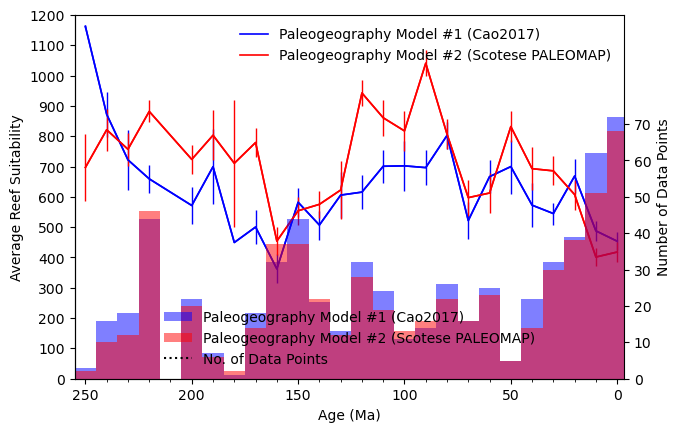

In [55]:

mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1200)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1210, 100))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(probs.keys(), list(zip(*probs.values()))[1], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
ax.errorbar(probs.keys(), list(zip(*probs.values()))[1], yerr=list(zip(*sems.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(probs.keys(), list(zip(*probs.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese PALEOMAP)')
ax.errorbar(probs.keys(), list(zip(*probs.values()))[0], yerr=list(zip(*sems.values()))[0], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')

# Hide the right and top spines
ax.spines[['right', 'top']].set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 71, 10))
ax2.set_ylabel('Number of Data Points')
ax2.hist(list(num.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*num.values()))[1], color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
ax2.hist(list(num.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*num.values()))[0], color='red', alpha=0.5, label='Paleogeography Model #2 (Scotese PALEOMAP)')

ax2.plot([], [], color='black', linestyle=':', label='No. of Data Points')


# ax2.plt()

ax.legend(loc='upper right', ncol=1, frameon=False)
ax2.legend(loc='lower center', ncol=1, frameon=False)

fig.savefig(f'probabilityComparison_SDM.png',dpi=300,transparent=True)


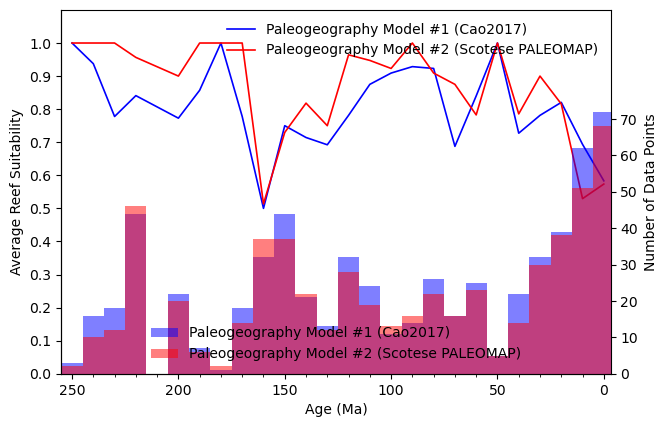

In [56]:
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1.1)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(percent_above_threshold.keys(), list(zip(*percent_above_threshold.values()))[1], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
# ax.errorbar(percent_above_threshold.keys(), list(zip(*percent_above_threshold.values()))[1], yerr=list(zip(*sems.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(percent_above_threshold.keys(), list(zip(*percent_above_threshold.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese PALEOMAP)')
# ax.errorbar(percent_above_threshold.keys(), list(zip(*percent_above_threshold.values()))[0], yerr=list(zip(*sems.values()))[0], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')

# Hide the right and top spines
ax.spines[['right', 'top']].set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 71, 10))
ax2.set_ylabel('Number of Data Points')
ax2.hist(list(num.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*num.values()))[1], color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
ax2.hist(list(num.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*num.values()))[0], color='red', alpha=0.5, label='Paleogeography Model #2 (Scotese PALEOMAP)')

# ax2.plot([], [], color='black', linestyle=':', label='No. of Data Points')


# ax2.plt()

ax.legend(loc='upper right', ncol=1, frameon=False)
ax2.legend(loc='lower center', ncol=1, frameon=False)

fig.savefig(f'probabilityComparison_threshold_SDM.png',dpi=300,transparent=True)